In [1]:
import numpy as np
import pandas as pd
import geopandas as gpd
import seaborn as sns
from matplotlib import pyplot as plt
from src.post_process_functions import format_output
from src.data import DATA_OUT_PROC, DATA_FIGURE, DATA_IN_JSONS, DATA_LABELLED
from src.accuracy import max_value_diff
from src.utils import *
from src.impact_def import IMPACT_SUBTYPES_MERGED


[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/lseverino/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package punkt to /Users/lseverino/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/lseverino/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


## Coverage with accuracy

In [2]:
#load data extracted for a specific model

keys = ["meta-llama_llama-4-scout-17b-16e-instruct", "llama-3.1-8b-instant", "llama-3.3-70b-versatile"]
key = keys[0]
res_savename_ext = f"merged_subtypes_post_processed_labelled_reports_DREF_target_{key}_v211025"
#f"post_processed_labelled_reports_{key}_v250925"
#f"post_processed_flags_labelled_reports_{key}_v250925"
#load data (labelled)
res_savename_lab = "merged_subtypes_post_processed_new_unit_std_labelled_reports_impacts_all_v111025"

split_lowest = False
suffix = "_geo_split_lowest" if split_lowest else "_geo"
suffix2 = suffix + "_v211025"
suffix3 = suffix + "_v171025"
#load geocoded data
extracted_df = gpd.read_file(DATA_OUT_PROC / (res_savename_ext+suffix2+".gpkg"))
labelled_df = gpd.read_file(DATA_OUT_PROC / (res_savename_lab+suffix3+".gpkg"))
#load corresponding matched data
filename_match = f"matched_data_ws6qt-ws5ql-geo-valuepre-strict-nans_{res_savename_ext}"
#f"matched_data_ws2-geo-valuepre-strict-nans_{res_savename_ext}"
matched_df = gpd.read_feather(DATA_OUT_PROC / (filename_match + ".feather"))

DEF_CRS_EPSG = "EPSG:4326"
drop_appeals = [
    "MDRCO023",
    "MDRGW003",
    "MDRHU005",
    "MDRPH021",
    "MDRRS015",
    "MDRMN017",
    "MDRGT009",
    "MDRPG008",
    "MDREC019",
    "MDRTN010",
    "MDRCR012",
    "MDRGE019",]
keep_appeals = [appeal for appeal in extracted_df["appealCode"].unique() if appeal not in drop_appeals]
for name in ["matched_df", "extracted_df", "labelled_df"]:
    df = locals()[name]
    df["quanti"] = df["impactValue"].notnull()
    df.loc[df["quanti"],"quanti"] = "quanti"
    df.loc[df["quanti"]==False,"quanti"] = "quali"
    df = df.set_crs(DEF_CRS_EPSG, allow_override=True)
    df = df[df["appealCode"].isin(keep_appeals)]
    locals()[name] = df  # assign back

#compute metrics
matched_df["impactValue_error"] = matched_df["impactValue_error"].replace([np.inf], np.nan)
matched_df["impactValue_sim"] = matched_df.apply(lambda x: 1-max_value_diff(x["impactValue"], x["impactValue_matched"]).clip(0,1), axis=1)


/var/folders/y5/t1z41tgj7dv50sm2_29dn8740000gp/T/ipykernel_17740/3891210162.py:41: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'quanti' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  df.loc[df["quanti"],"quanti"] = "quanti"
/var/folders/y5/t1z41tgj7dv50sm2_29dn8740000gp/T/ipykernel_17740/3891210162.py:41: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'quanti' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  df.loc[df["quanti"],"quanti"] = "quanti"
/var/folders/y5/t1z41tgj7dv50sm2_29dn8740000gp/T/ipykernel_17740/3891210162.py:41: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'quanti' has dtype incompatible with bool, please explicitly cast to a compatible dtype fir

In [3]:
## add other variables useful for analysis
#report length
extracted_df["reportSize"] = extracted_df["nathaz_text"].apply(len)

#report type
file_path = DATA_IN_JSONS / "preproc_filtered_report_types_nat_hazards_bugfix_v240925.csv"#'all_ifrc_reports_info_processed_extended_format_nb_std_units.json' "nathaz_ifrc_reports_info_processed.json"
ifrc_reports_df = pd.read_csv(file_path)

keys = labelled_df[['appealCode', 'reportDate']].drop_duplicates()
labelled_reports_raw = ifrc_reports_df.merge(keys, on=['appealCode', 'reportDate'], how='inner')


#add vars to dfs
extracted_df = extracted_df.merge(labelled_reports_raw[["appealCode", "reportDate", "appealType"]], how="left", on=["appealCode", "reportDate"])
labelled_df = labelled_df.merge(labelled_reports_raw[["appealCode", "reportDate", "appealType"]], how="left", on=["appealCode", "reportDate"])
matched_df = matched_df.merge(labelled_reports_raw[["appealCode", "reportDate", "appealType"]], how="left", on=["appealCode", "reportDate"])


In [4]:

def filter_matches(matched_df, value_error_th=0.05, sim_th=0.6, match_cat=["impactSubtype"]):
    """Filter matches based on value error threshold for quantitative and similarity threshold for qualitative"""
    #filter matches
    matched_df_filter_qt = matched_df.copy()
    matched_df_filter_qt = matched_df_filter_qt[(matched_df_filter_qt["match_sim"] >= sim_th) & (matched_df_filter_qt["impactValue_error"] <= value_error_th) & (matched_df_filter_qt["quanti"]=="quanti")]
    matched_df_filter_ql = matched_df.copy()
    matched_df_filter_ql = matched_df_filter_ql[(matched_df_filter_ql["match_sim"] >= sim_th) & (matched_df_filter_ql["quanti"]=="quali")]
    if match_cat:
        matched_df_filter_ql = pd.concat([matched_df_filter_ql.query(f"{cat} == {cat}_matched").dropna(how="all",axis=0) for cat in match_cat]).sort_index()
    return pd.concat([matched_df_filter_qt, matched_df_filter_ql], axis=0)

def make_coverage_accuracy_df(extracted_df, labelled_df, matched_df_filter, group_key, group_keys=None, keep_vars=[]):
    """Make coverage df filtering matches by accuracy and grouped by group_key"""

    df_list = []
    for qq in ["quanti", "quali"]:
        labelled_dfq = labelled_df[labelled_df["quanti"]==qq]
        extracted_dfq = extracted_df[extracted_df["quanti"]==qq]
        matched_df_filterq = matched_df_filter[matched_df_filter["quanti"]==qq]
        metrics_by_key = {}
        if group_key == None:
            metrics_by_key["nb labelled"] = len(labelled_dfq)
            metrics_by_key["nb extracted"] = len(extracted_dfq)
            metrics_by_key["coverage"] = 100*len(extracted_dfq)/len(labelled_dfq) if len(labelled_dfq) > 0 else np.nan
            metrics_by_key["nb matches"] = matched_df_filterq["lab_match_id_sim"].nunique()
            metrics_by_key["coverage matches"] = 100*metrics_by_key["nb matches"]/len(labelled_dfq) if len(labelled_dfq) > 0 else np.nan
            metrics_by_key["nb garbage"] = max(0,len(extracted_dfq) - metrics_by_key["nb matches"])
            metrics_by_key["garbage"] = 100*(metrics_by_key["nb garbage"] / len(extracted_dfq)) if len(extracted_dfq) > 0 else 0
            metrics_by_key["garbage/coverage"] = metrics_by_key["nb garbage"] / metrics_by_key["nb matches"] if metrics_by_key["nb matches"] > 0 else np.nan
            metrics_by_key["quanti"] = qq

            print(f'Overall average {qq}: {metrics_by_key["nb extracted"]} extracted, {metrics_by_key["nb labelled"]} labelled, {metrics_by_key["nb matches"]} correct matches, {metrics_by_key["nb garbage"]} garbage matches')
            df_list.append(pd.DataFrame(metrics_by_key, index=[0]))
        else:
            if group_keys is None:
                group_keys = labelled_df[group_key].unique()
            for group_id in group_keys:
                group_lab = labelled_dfq[labelled_dfq[group_key] == group_id]
                group_ext = extracted_dfq[extracted_dfq[group_key] == group_id]
                group_ext_match = matched_df_filterq[matched_df_filterq[group_key] == group_id]
                metrics_by_key["nb labelled"] = len(group_lab)
                metrics_by_key["nb extracted"] = len(group_ext)
                metrics_by_key["coverage"] = 100*len(group_ext)/len(group_lab) if len(group_lab) > 0 else np.nan
                metrics_by_key["nb matches"] = group_ext_match["lab_match_id_sim"].nunique()
                metrics_by_key["coverage matches"] = 100*metrics_by_key["nb matches"]/len(group_lab) if len(group_lab) > 0 else np.nan
                metrics_by_key["nb garbage"] = max(0,len(group_ext) - metrics_by_key["nb matches"])
                metrics_by_key["garbage"] = 100*(metrics_by_key["nb garbage"] / len(group_ext)) if len(group_ext) > 0 else 0
                metrics_by_key["garbage/coverage"] = metrics_by_key["nb garbage"] / metrics_by_key["nb matches"] if metrics_by_key["nb matches"] > 0 else np.nan
                metrics_by_key["quanti"] = qq
                if len(keep_vars):
                    for keep_var in keep_vars:
                        if keep_var != group_key and len(group_ext):
                            metrics_by_key[keep_var] = group_ext[keep_var].head(1).values[0]
                df_list.append(pd.DataFrame(metrics_by_key, index=[group_id]))
    return pd.concat(df_list)


In [5]:
extracted_df.impactSubtype.value_counts()

impactSubtype
Agriculture and Access to Food                                                                45
Water, Sanitation, and Hygiene Infrastructure and Access to Water, Sanitation, and Hygiene    28
Residential Buildings                                                                         24
Affected People                                                                               20
Healthcare Infrastructure and Access to Healthcare                                            19
Targeted People                                                                               18
Transportation Infrastructure and Access to Mobility                                          18
DREF Allocation                                                                               18
Human Health and Wellbeing                                                                    16
Displaced People                                                                              14
Other Economic A

In [ ]:
from src.sanity_checks import flag_remove_cat
remove_cats = ["DREF Allocation", "Targeted People", "Assisted People", "Other Human Impacts", "Other Infrastructural Impacts", "Other Agricultural Impacts", "Other Service Access Impacts"]
extracted_df["flag_remove_cat"] = extracted_df.apply(flag_remove_cat, remove_cats=remove_cats, axis=1)
labelled_df["flag_remove_cat"] = labelled_df.apply(flag_remove_cat, remove_cats=remove_cats, axis=1)
matched_df["flag_remove_cat"] = matched_df.apply(flag_remove_cat, remove_cats=remove_cats, axis=1)

In [7]:
#define threshold above which we consider a match
from src.impact_def import IMPACT_SUBTYPES


value_error_th = 0.1
sim_th = 0.5
filter_flags = ["flag_unit_nonstd", "flag_percent", "flag_remove_cat"]#["flag_unit_nonstd"
extracted_df_filter = filter_by_flags(extracted_df, flag_filters=filter_flags)
labelled_df_filter = filter_by_flags(labelled_df, flag_filters=filter_flags)
matched_df_filter1 = filter_by_flags(matched_df, flag_filters=filter_flags)
matched_df_filter2 = filter_matches(matched_df_filter1, value_error_th=value_error_th, sim_th=sim_th)
coverage_df_match = make_coverage_accuracy_df(extracted_df_filter, labelled_df_filter, matched_df_filter2, group_key=None)
coverage_df_match_appeal = make_coverage_accuracy_df(extracted_df_filter, labelled_df_filter, matched_df_filter2, group_key="appealCode", keep_vars=["appealType", "reportSize", "reportDate"]).reset_index(drop=False, names=["appealCode"])
coverage_df_match_subtype = make_coverage_accuracy_df(extracted_df_filter, labelled_df_filter, matched_df_filter2, group_key="impactSubtype", group_keys=IMPACT_SUBTYPES_MERGED).reset_index(drop=False, names=["impactSubtype"])

Overall average quanti: 117 extracted, 319 labelled, 95 correct matches, 22 garbage matches
Overall average quali: 121 extracted, 152 labelled, 82 correct matches, 39 garbage matches


In [ ]:
from matplotlib.patches import bbox_artist
from matplotlib.pyplot import subplot

def plot_coverage_match_v2(df, subplot_col, hue_col, yvar, xlabel="%", value_col="value",palette=None, add_avg=True, fig=None):
    subplot_vars = df[subplot_col].unique()
    hue_vars = df[hue_col].unique()
    if not palette:
        palette = sns.color_palette("colorblind", len(hue_vars))
    if fig is None:
        fig, ax = plt.subplots(1, len(subplot_vars), figsize=(15, 8), sharey=True)
    else:
        ax = fig.get_axes()
    for i, val in enumerate(subplot_vars):
        val_df = df[df[subplot_col] == val]
        ipal = palette[2*i:2*(i+1)]
        sns.barplot(
            data=val_df,
            x=value_col, y=yvar,
            hue=hue_col,
            #hue_order=hue_order,
            palette=ipal,
            ax=ax[i]
        )

        #add average coverage line
        if add_avg:
            for j, var in enumerate(hue_vars):
                mean_val = val_df[val_df[hue_col] == var].groupby(yvar)[value_col].mean().mean()
                #mean_val = df[(df[yvar] == "Overall average") & (df[hue_col] == var) & (df[subplot_col] == val)][value_col].values[0]
                ax[i].axvline(mean_val, color=ipal[j], linestyle="--", linewidth=2)
                ax[i].text(
                    mean_val, 2+2*j, f"Average {var}: {mean_val:.2f}"
                    , color=ipal[j], ha="left", va="center", backgroundcolor="white"
                )
        ax[i].set_title(val)
        ax[i].set_ylabel(yvar)
        ax[i].set_xlabel(xlabel)
        ax[i].legend(loc="lower right")
    return fig, ax


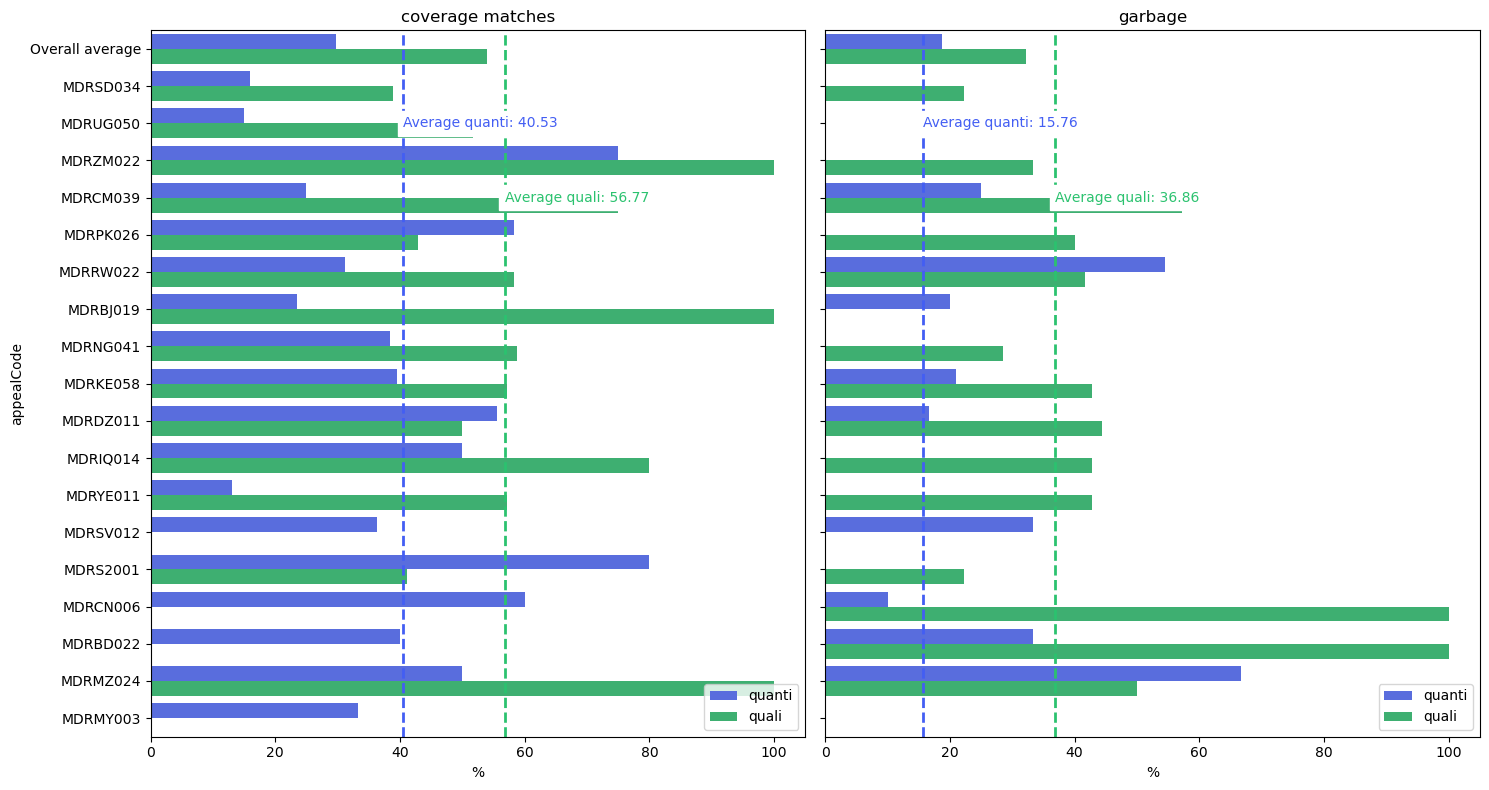

In [13]:
value_vars = ["coverage matches", "garbage"]#["nb labelled","nb matches", "nb garbage"]#["nb labelled","nb matches", "nb garbage"]#["coverage matches", "garbage"]#["nb matches", "nb garbage"]
xlabels = ["%", "%"]#["#", "#", "#"]#["%", "%"]#["#", "#", "#"]
yvar="appealCode"
add_avg = True
if yvar == "appealCode":
    coverage_df_match_yvar = coverage_df_match_appeal
    #sort by to look for trends
    size_index = extracted_df.groupby("appealCode").head(1).sort_values("reportSize", ascending=False)["appealCode"]
    coverage_df_match_yvar["appealCode"] = pd.Categorical(coverage_df_match_yvar["appealCode"], categories=size_index, ordered=True)
    coverage_df_match_yvar = coverage_df_match_yvar.sort_values("appealCode") #sort by size
    plot_df = coverage_df_match_yvar.melt(id_vars=[yvar,"reportSize", "reportDate", "appealType", "quanti"], value_vars=value_vars, var_name="match", value_name="value")

elif yvar == "impactSubtype":
    coverage_df_match_yvar = coverage_df_match_subtype
    coverage_df_match_yvar = coverage_df_match_yvar.sort_values("nb labelled", ascending=False) #sort by nb labelled
    plot_df = coverage_df_match_yvar.melt(id_vars=[yvar, "quanti"], value_vars=value_vars, var_name="match", value_name="value")
    plot_df = plot_df[~plot_df["impactSubtype"].isin(["DREF Allocation", "Targeted People", "Assisted People"])]
if add_avg:
    average_df_match = coverage_df_match.melt(id_vars=["quanti"], value_vars=value_vars, var_name="match", value_name="value")
    average_df_match[yvar] ="Overall average"
    plot_df = pd.concat([average_df_match, plot_df], axis=0).reset_index(drop=True)
#choose plotting cols
subplot_col = "match"#"quanti""match"
hue_col = "quanti"#"quanti""match"
palette_rel = ["#E61F04", "#f46c6c","#177093","#27a4d6"]
palette_rel = ["#435EF3", "#2bc26f","#435EF3", "#2bc26f", "#435EF3", "#2bc26f"]
fig, ax = plt.subplots(1, len(value_vars), figsize=(15, 8), sharey=True, sharex=False)
fig, axes = plot_coverage_match_v2(plot_df, subplot_col, hue_col, yvar=yvar, value_col="value", palette=palette_rel, add_avg=add_avg, fig=fig)
[ax.set_xlabel(xlabels[i]) for i, ax in enumerate(axes)]
#ylabels = [ax.get_yticklabels() for ax in axes]
#new_ylabs = []
#for i, ylab in enumerate(ylabels[0]):
#    lab_text = ylab.get_text()
#    if lab_text=="Water, Sanitation, and Hygiene Infrastructure and Access to Water, Sanitation, and Hygiene":
#        new_txt = "Water, Sanitation and Hygiene Infrastructure\nand Access to Water, Sanitation and Hygiene"
#    elif lab_text=="Power and Energy Production Infrastructure and Access to Power and Energy":
#        new_txt = "Power and Energy Production Infrastructure\nand Access to Power and Energy"
#    elif lab_text == "IT and Communication Infrastructure and Access to IT and Communication":
#        new_txt = "IT and Communication Infrastructure\nand Access to IT and Communication"
#    else:
#        new_txt = lab_text
#    new_ylabs.append(new_txt)
#axes[0].set_yticklabels(new_ylabs)
#axes[1].set_xlim(0, 25)
#axes[2].set_xlim(0, 25)
#fig.suptitle(f"Coverage matches by {yvar}\n{key}\nvalue_error_thresh={value_error_th}, sim_thresh={sim_th}")
fig.tight_layout()
fig.savefig(DATA_FIGURE / f"coverage_matches_by_{yvar}_{subplot_col}_vth-{value_error_th}_sth-{sim_th}_flt_{filename_match}.png", bbox_inches="tight", dpi=300)

In [38]:
cat = "Health Infrastructure and Access to Healthcare"
ext_df = extracted_df_filter[extracted_df_filter["impactSubtype"]==cat]
lab_df = labelled_df_filter[labelled_df_filter["impactSubtype"]==cat]
m_df = matched_df_filter2[matched_df_filter2["impactSubtype"]==cat]
make_coverage_accuracy_df(ext_df, lab_df, m_df, group_key="impactSubtype", group_keys=[cat]).reset_index(drop=False, names=["impactSubtype"])

,impactSubtype,nb labelled,nb extracted,coverage,nb matches,coverage matches,nb garbage,garbage,garbage/coverage,quanti
0,Health Infrastructure and Access to Healthcare,0,0,NaN,0,NaN,0,0,NaN,quanti
1,Health Infrastructure and Access to Healthcare,0,0,NaN,0,NaN,0,0,NaN,quali


In [56]:
print_match(matched_df_filter1[(matched_df_filter1["impactSubtype_sim"] <= 0.8)]).value_counts("impactSubtype")

impactSubtype
Other Human Impacts                                                                           22
Healthcare Infrastructure and Access to Healthcare                                            20
Other Infrastructural Impacts                                                                 19
Human Health and Wellbeing                                                                    18
Other Service Access Impacts                                                                  15
Power and Energy Production Infrastructure and Access to Power and Energy                     12
Other Economic Activity & Livelihood Production                                               10
Water, Sanitation, and Hygiene Infrastructure and Access to Water, Sanitation, and Hygiene     9
Education Infrastructure and Access to Education                                               6
Transportation Infrastructure and Access to Mobility                                           5
Homeless People 

In [159]:
un_matched = matched_df_filter1[(matched_df_filter1["match_sim"] <= 0.5) & (matched_df_filter1["quanti"] == "quali")]
for groupid, group in un_matched.groupby("impactSubtype"):
    print(groupid)
    print(group.value_counts("impactSubtype_matched"))

Access to Food
impactSubtype_matched
Other Infrastructural Impacts                      3
Other Economic Activity & Livelihood Production    2
Residential Buildings                              2
Water, Sanitation, and Hygiene Infrastructure      2
Affected Livestock and Animals                     1
Crop Production and Forestry                       1
Education Infrastructure                           1
Healthcare Infrastructure                          1
Human Health and Wellbeing                         1
Other Service Access Impacts                       1
Water Quality and Availability                     1
Name: count, dtype: int64
Access to Healthcare
impactSubtype_matched
Other Economic Activity & Livelihood Production    3
Residential Buildings                              3
Road Infrastructure                                2
Water Quality and Availability                     2
Access to Food                                     1
Agricultural Infrastructure                   

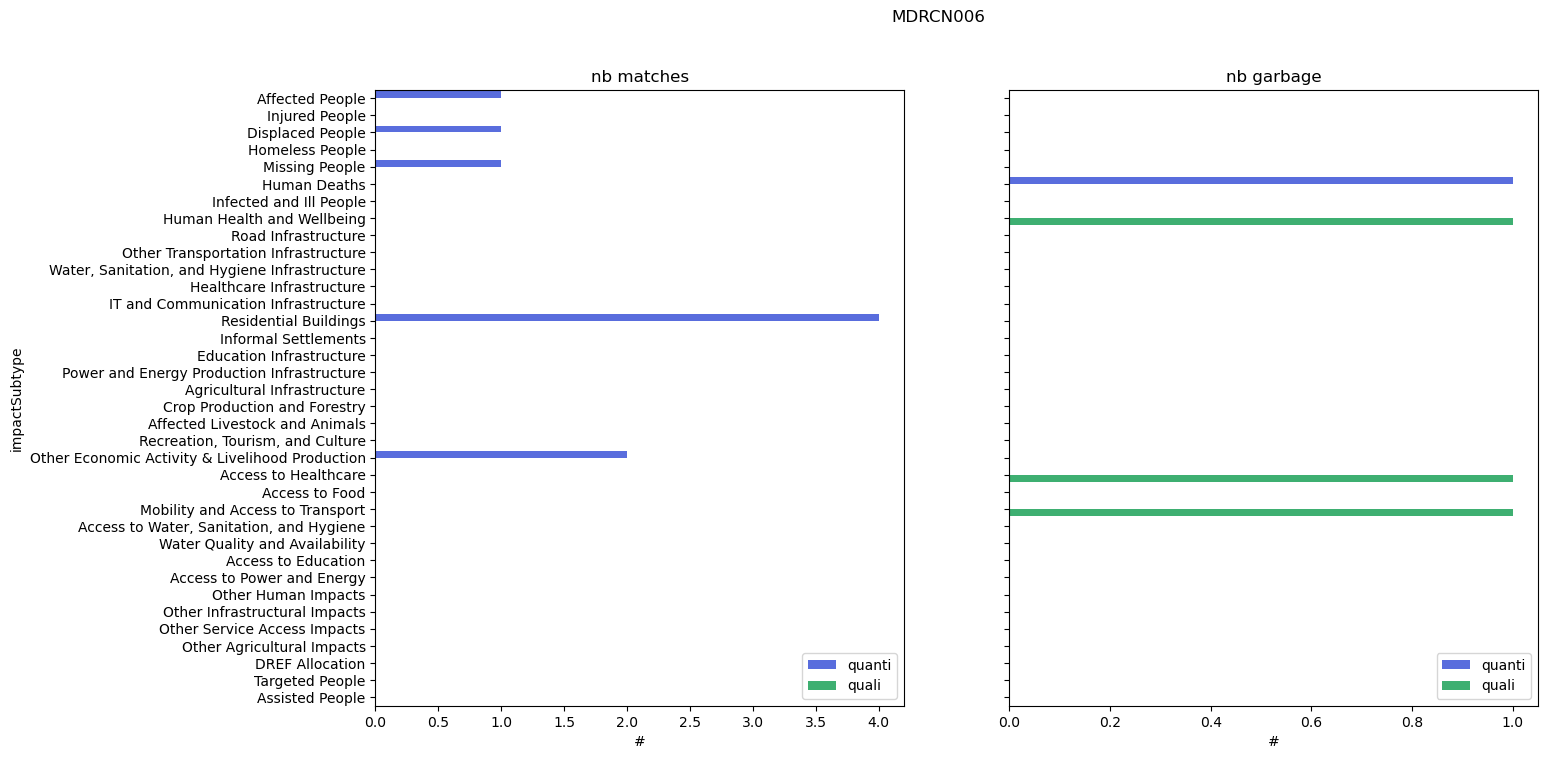

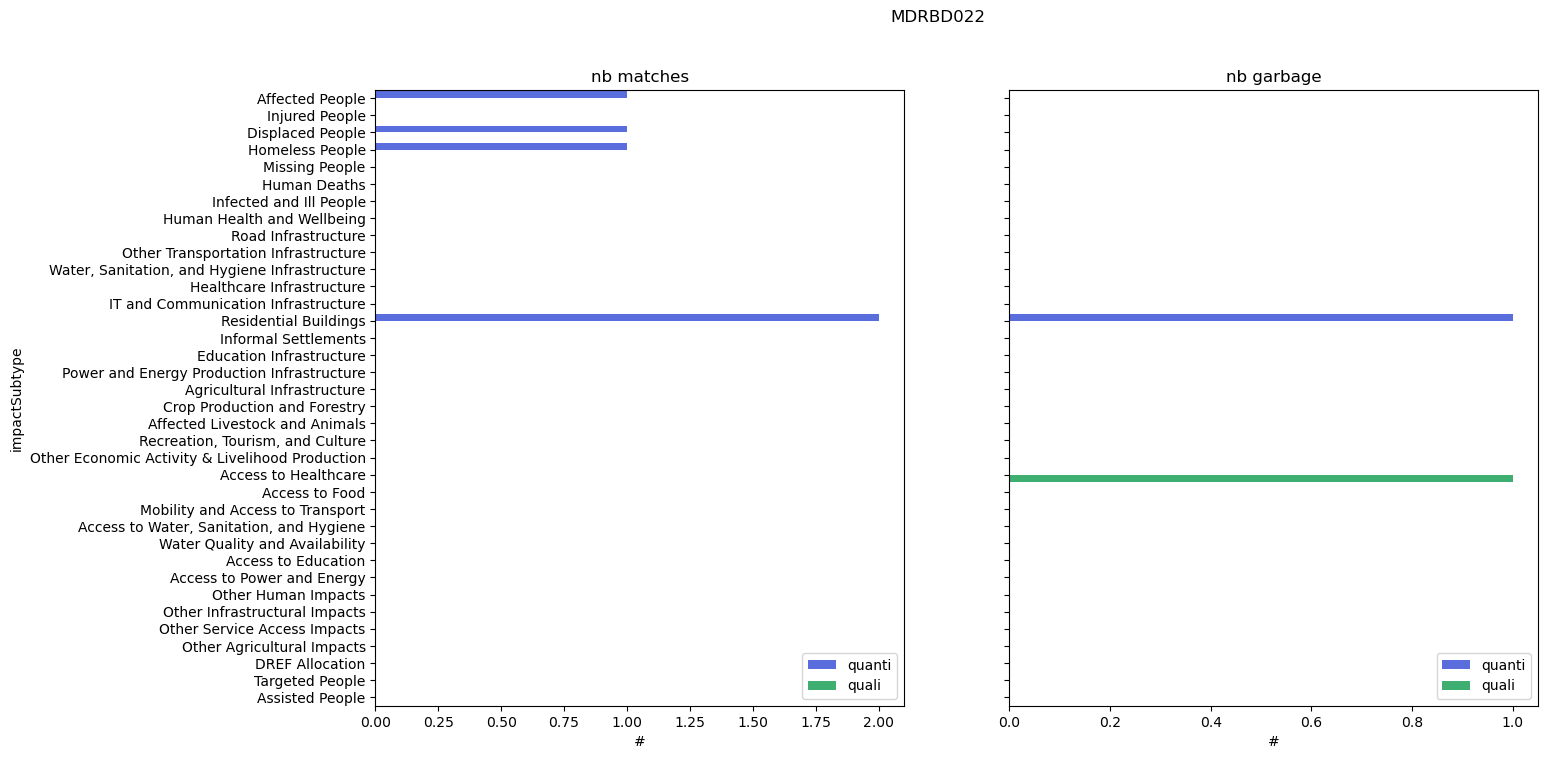

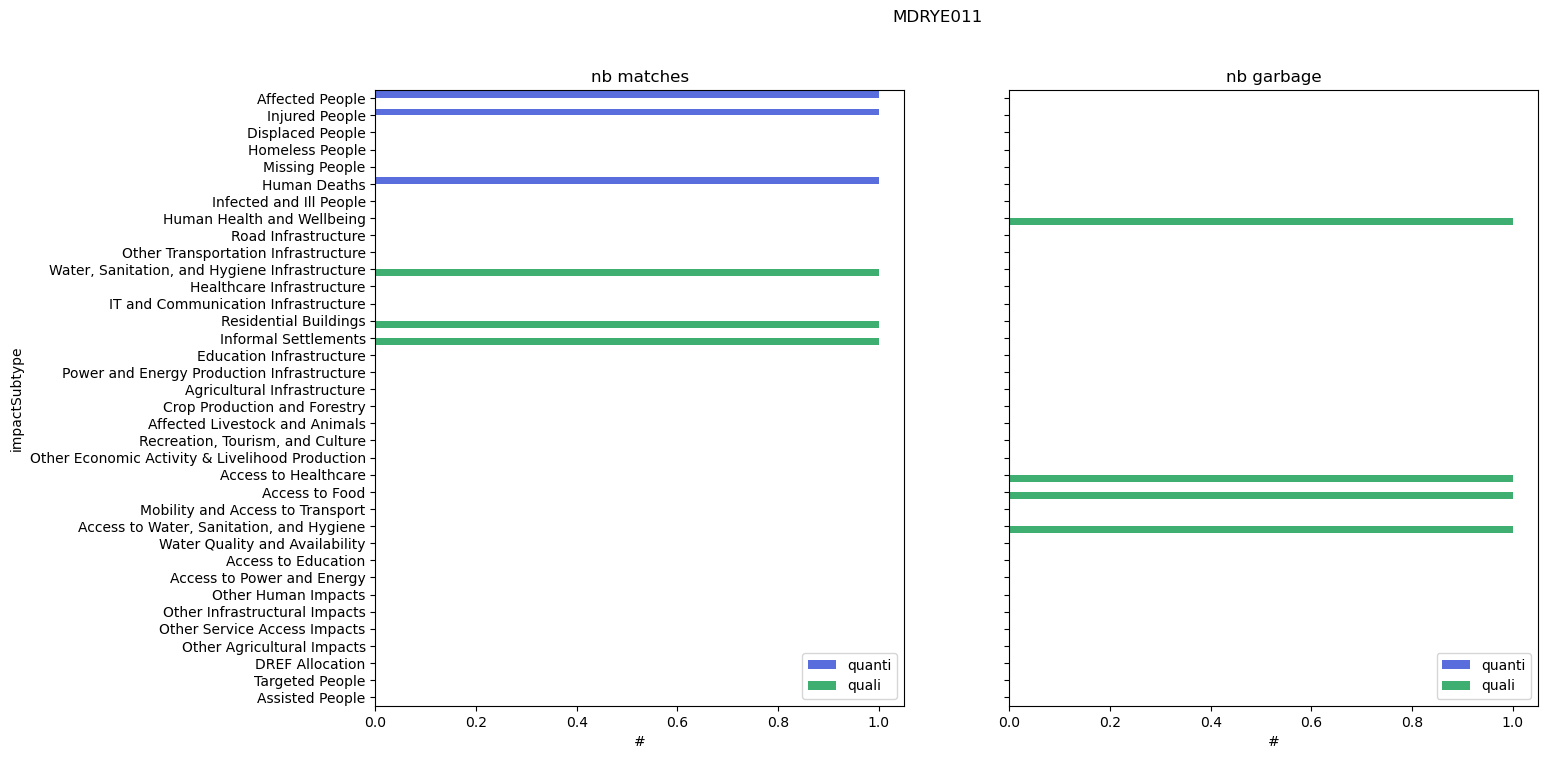

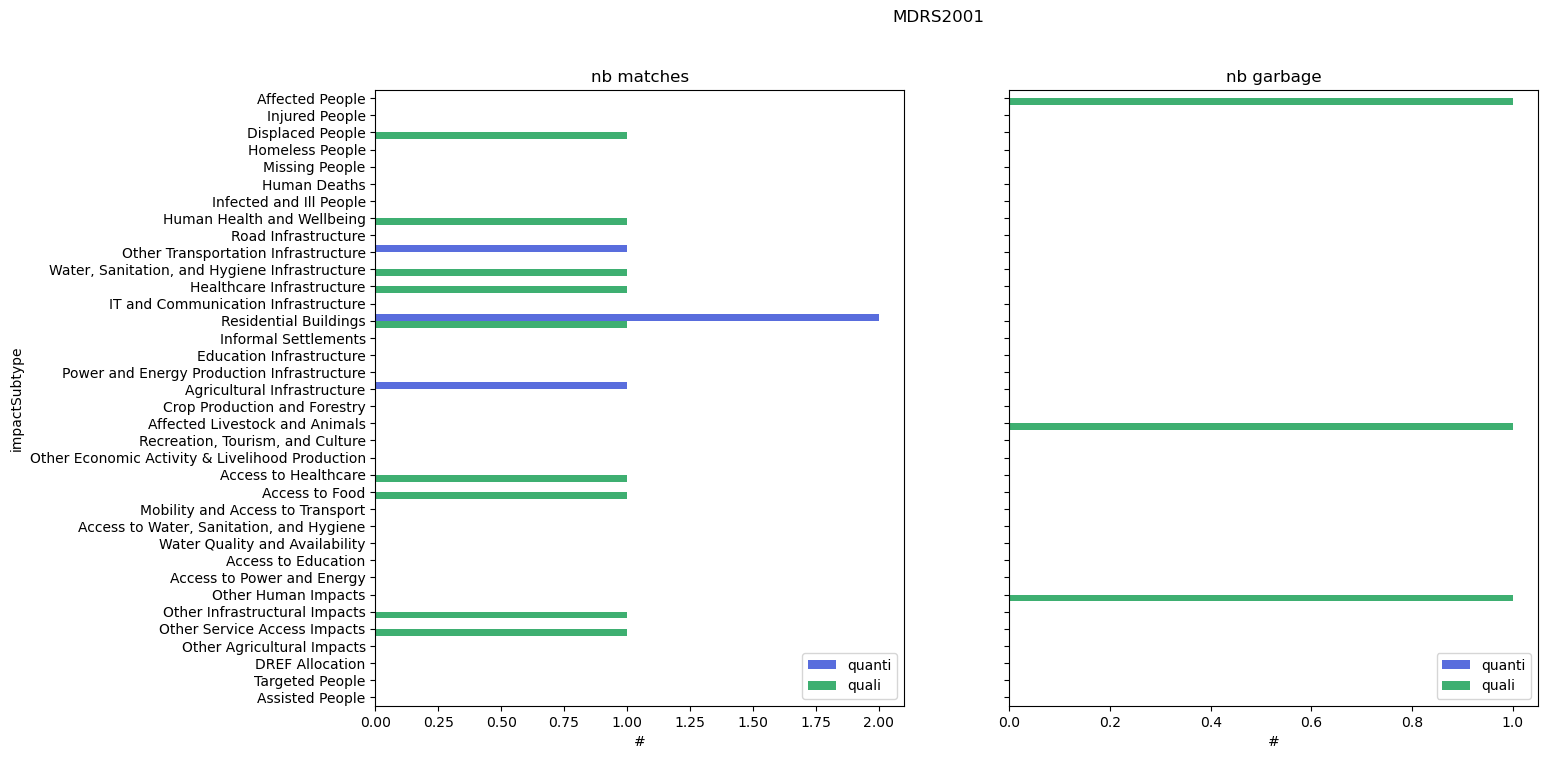

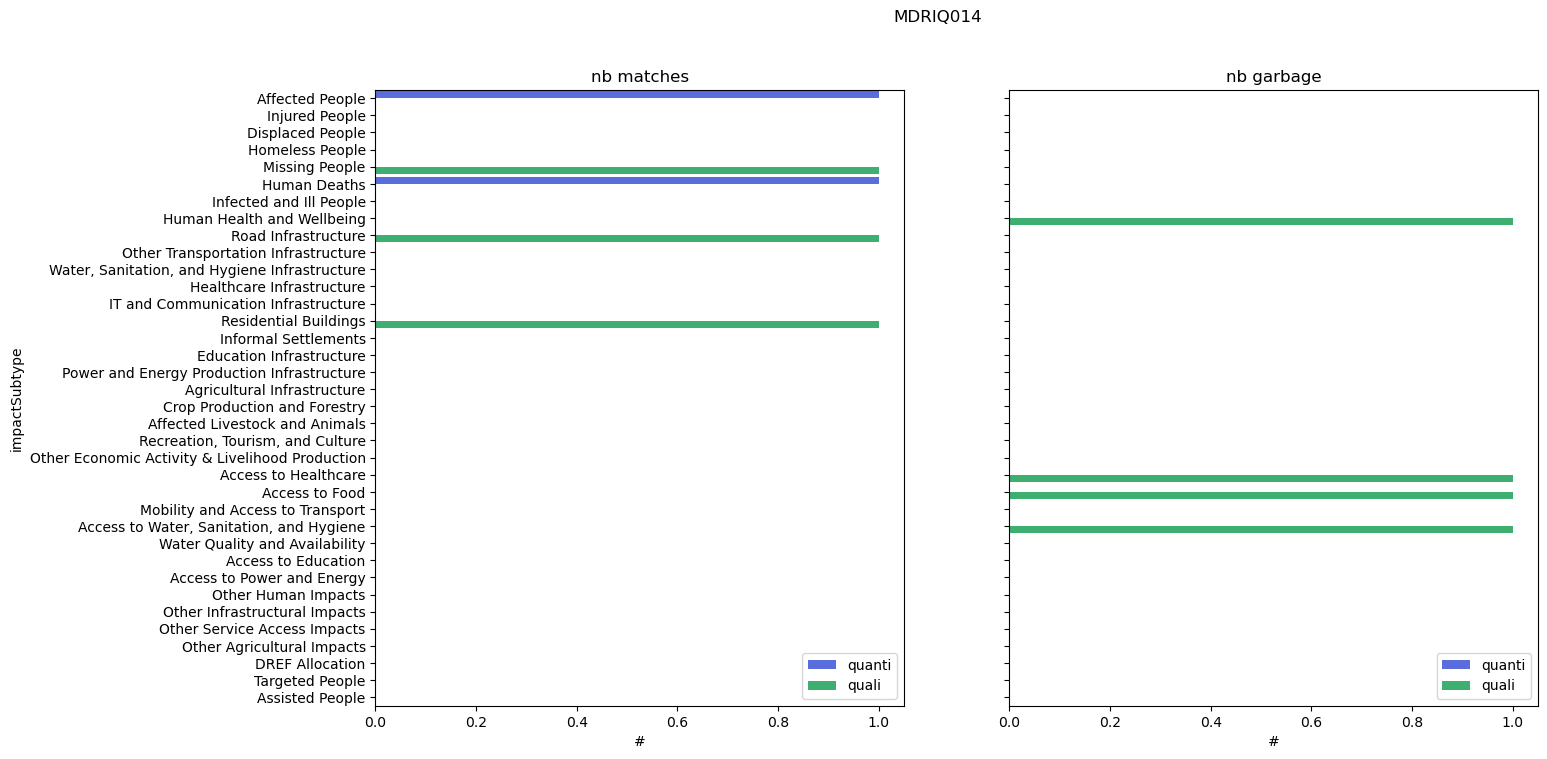

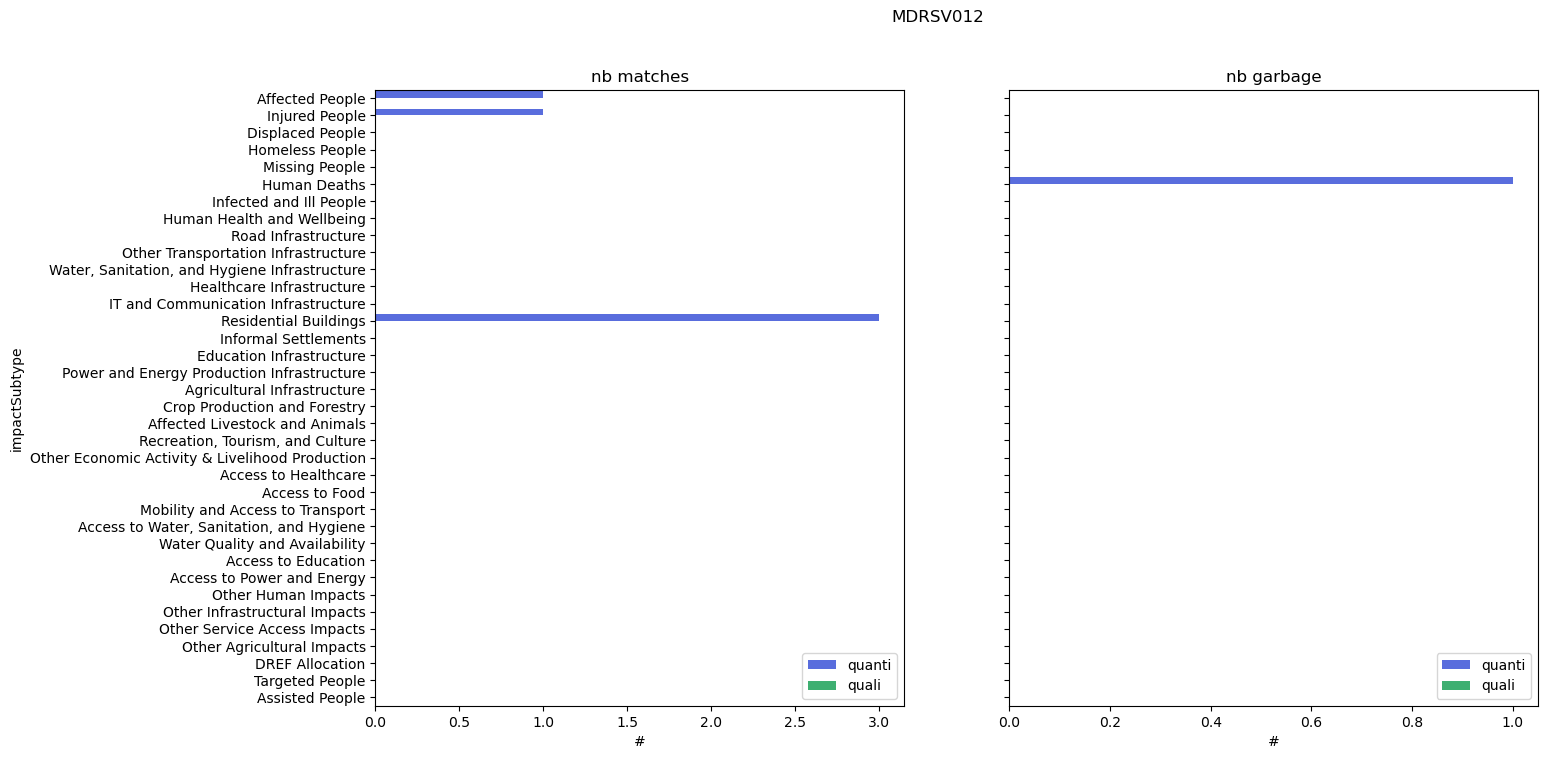

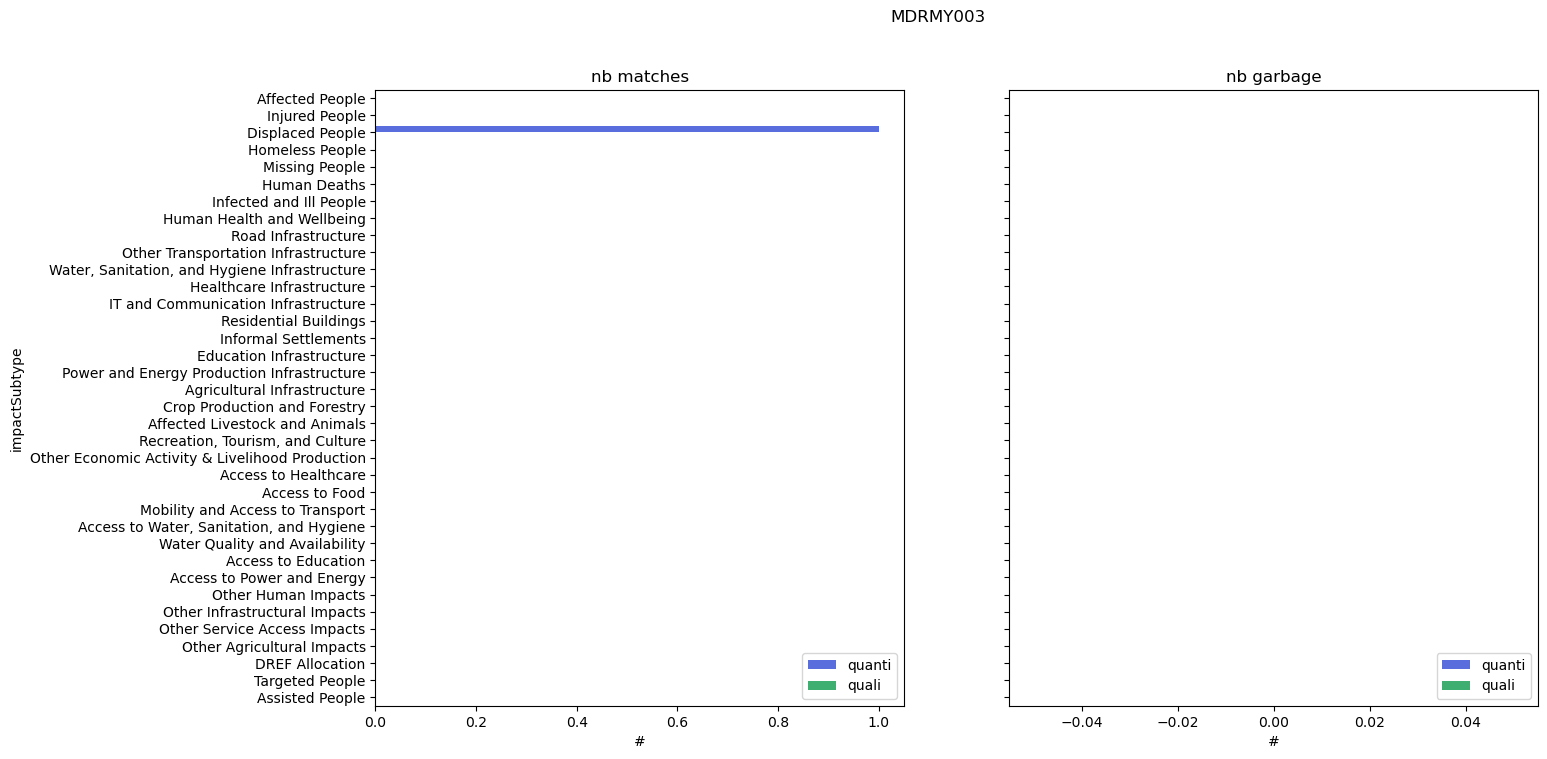

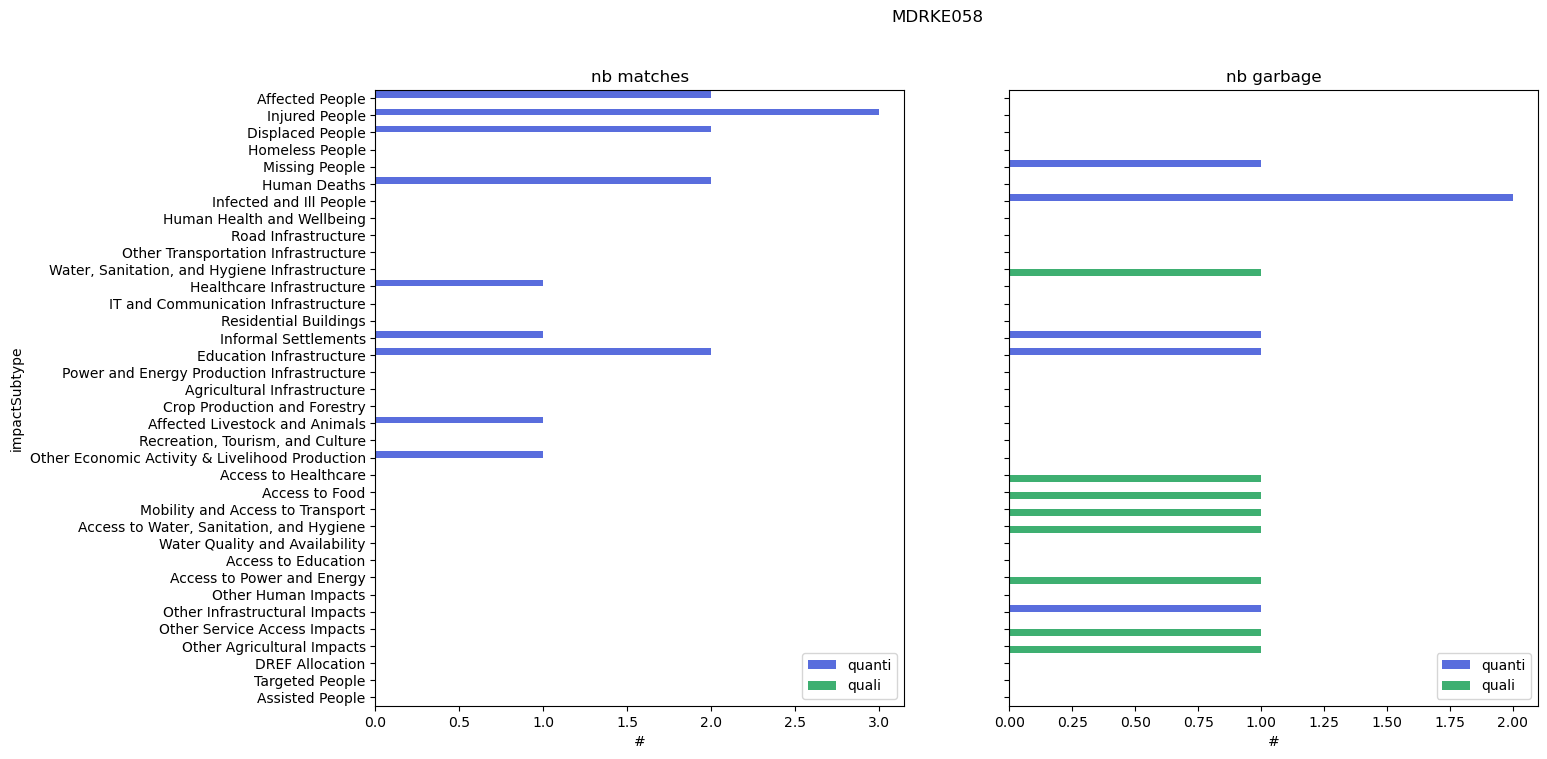

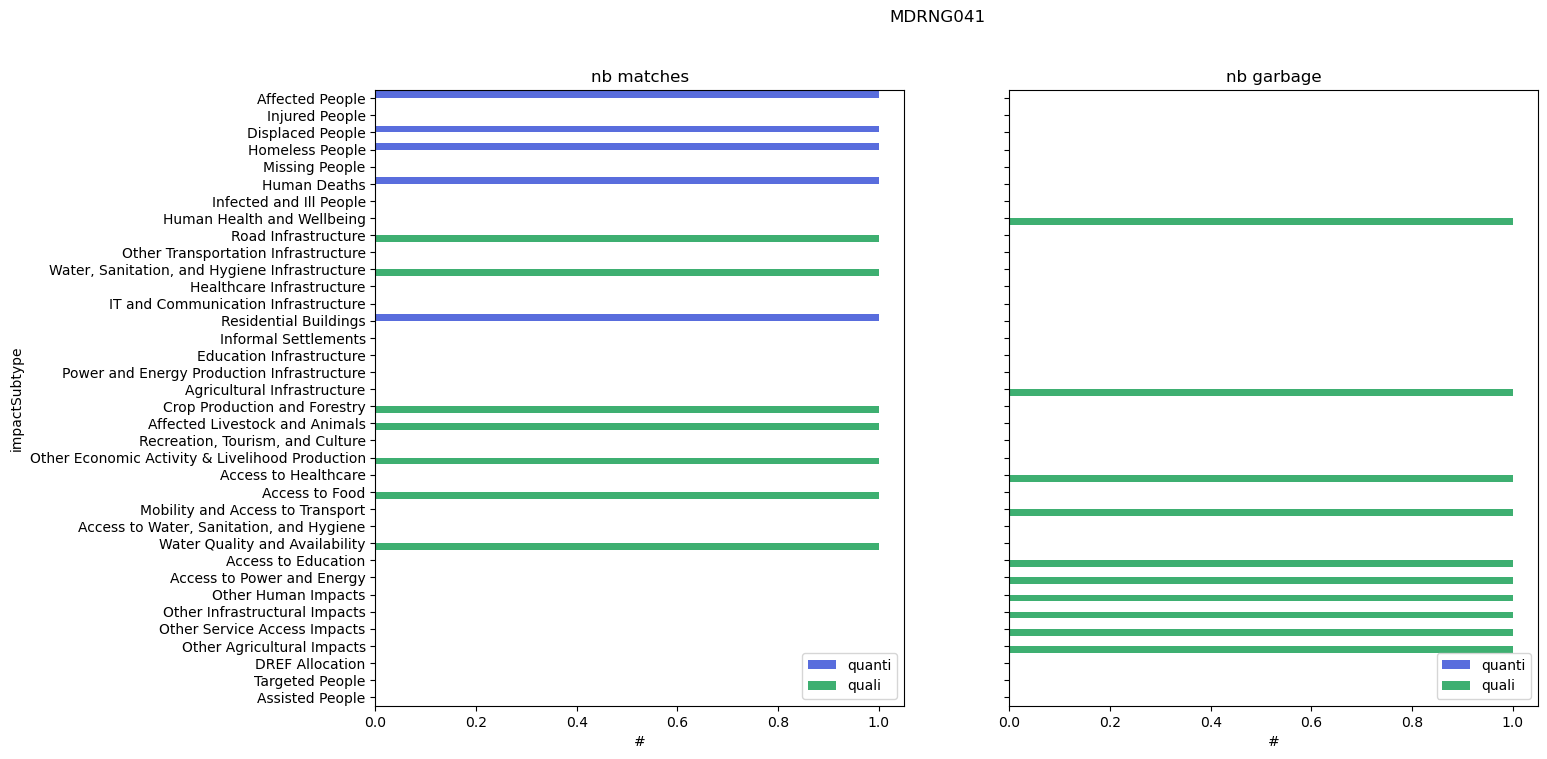

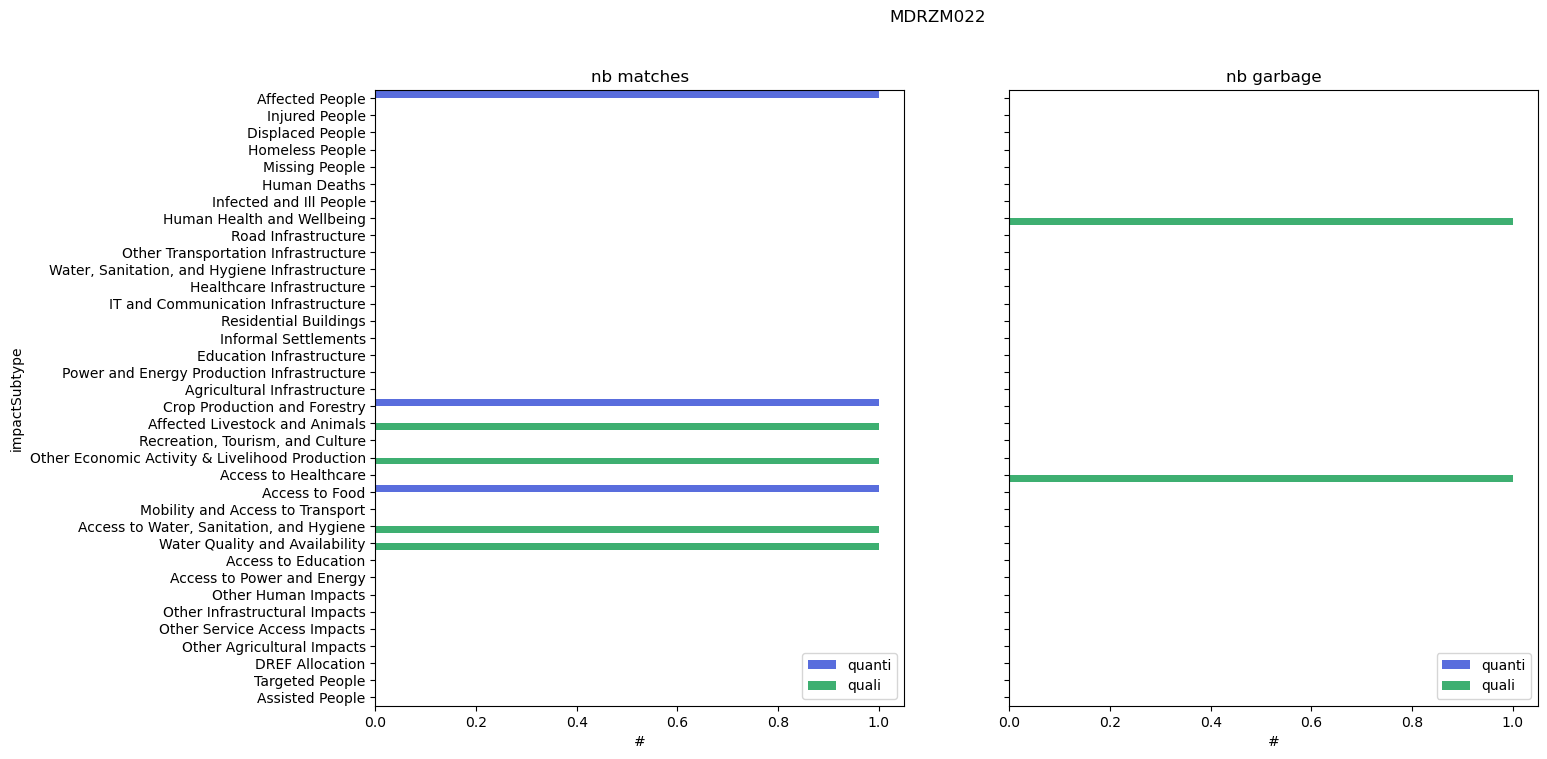

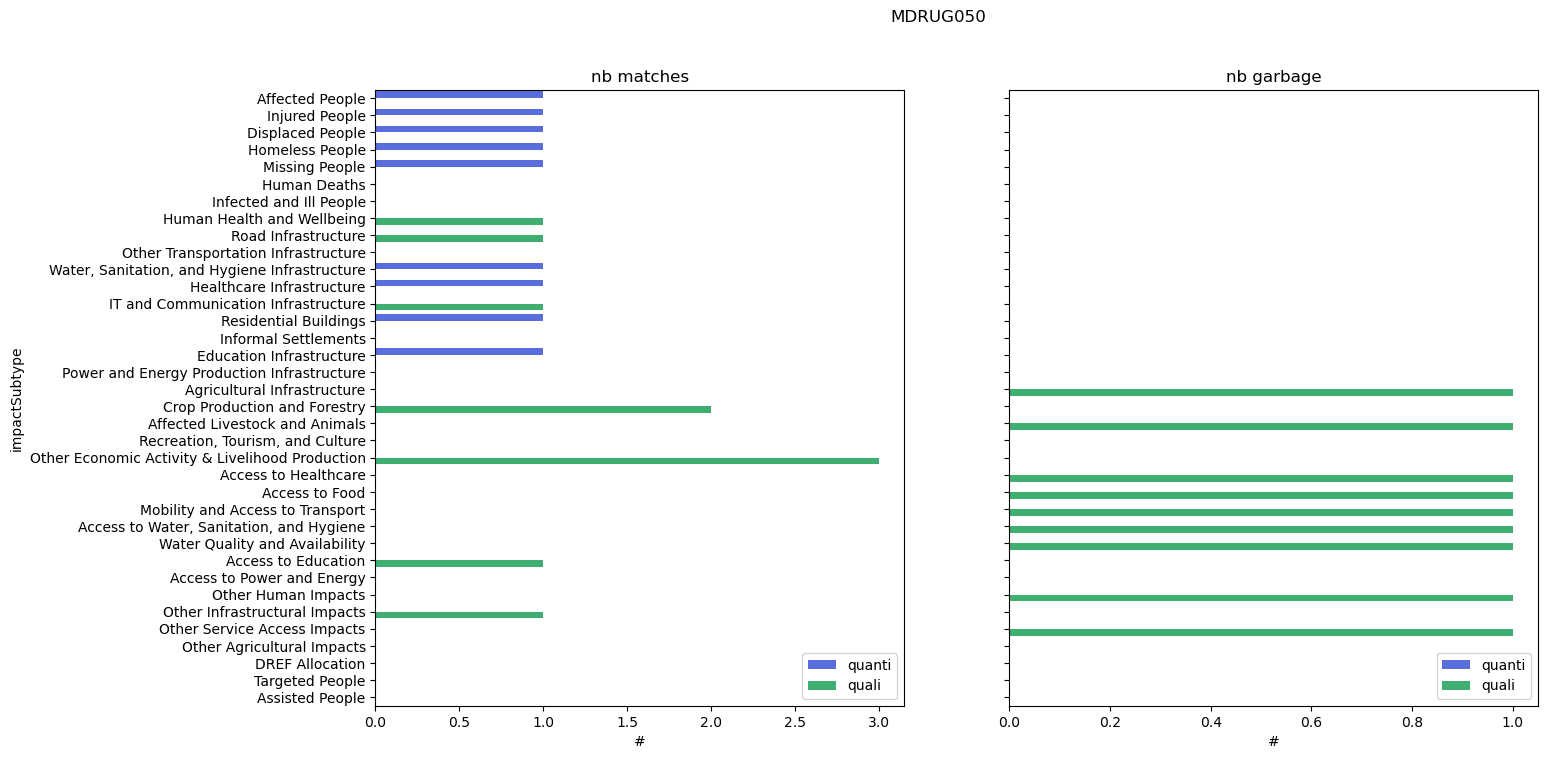

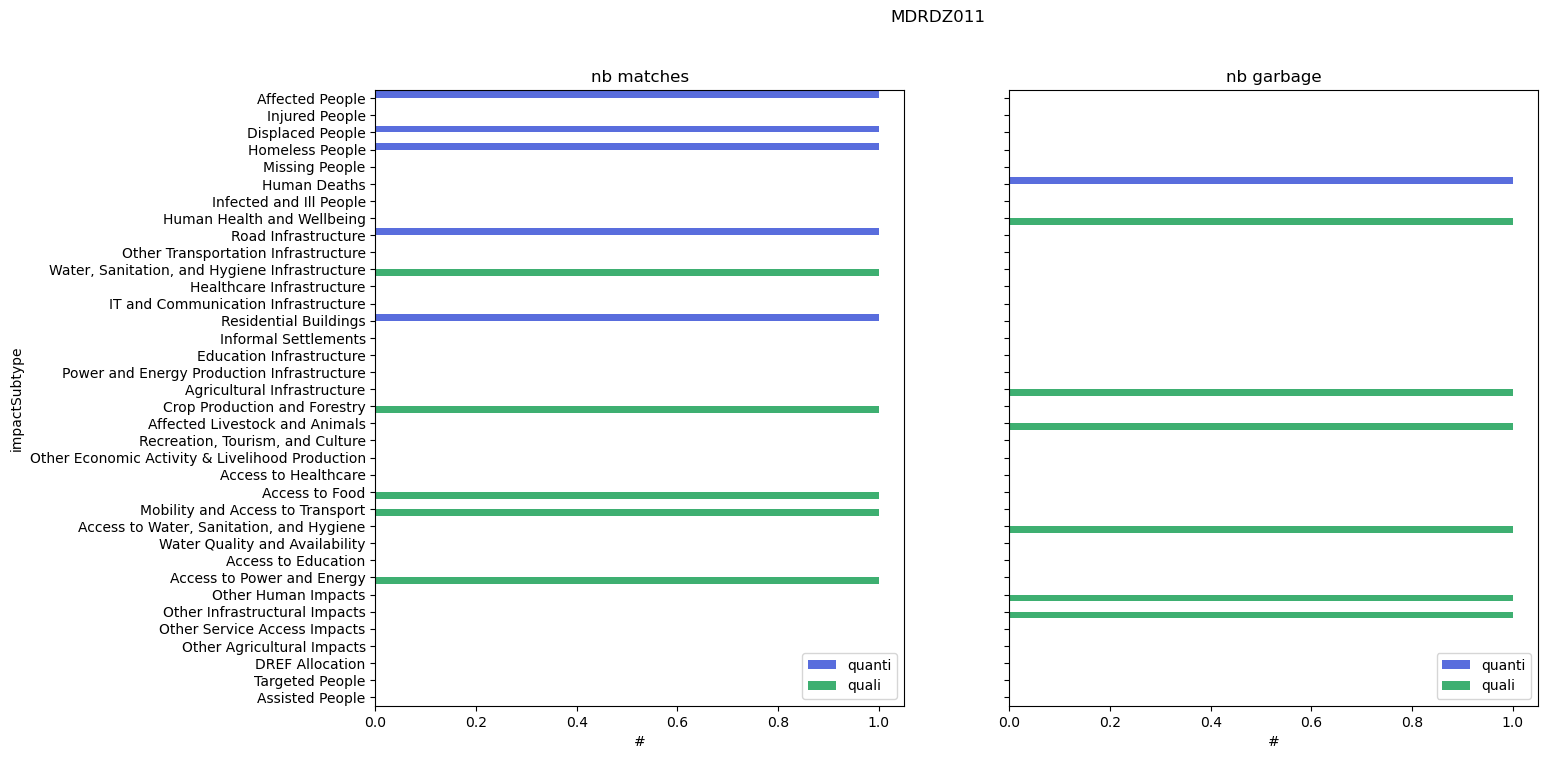

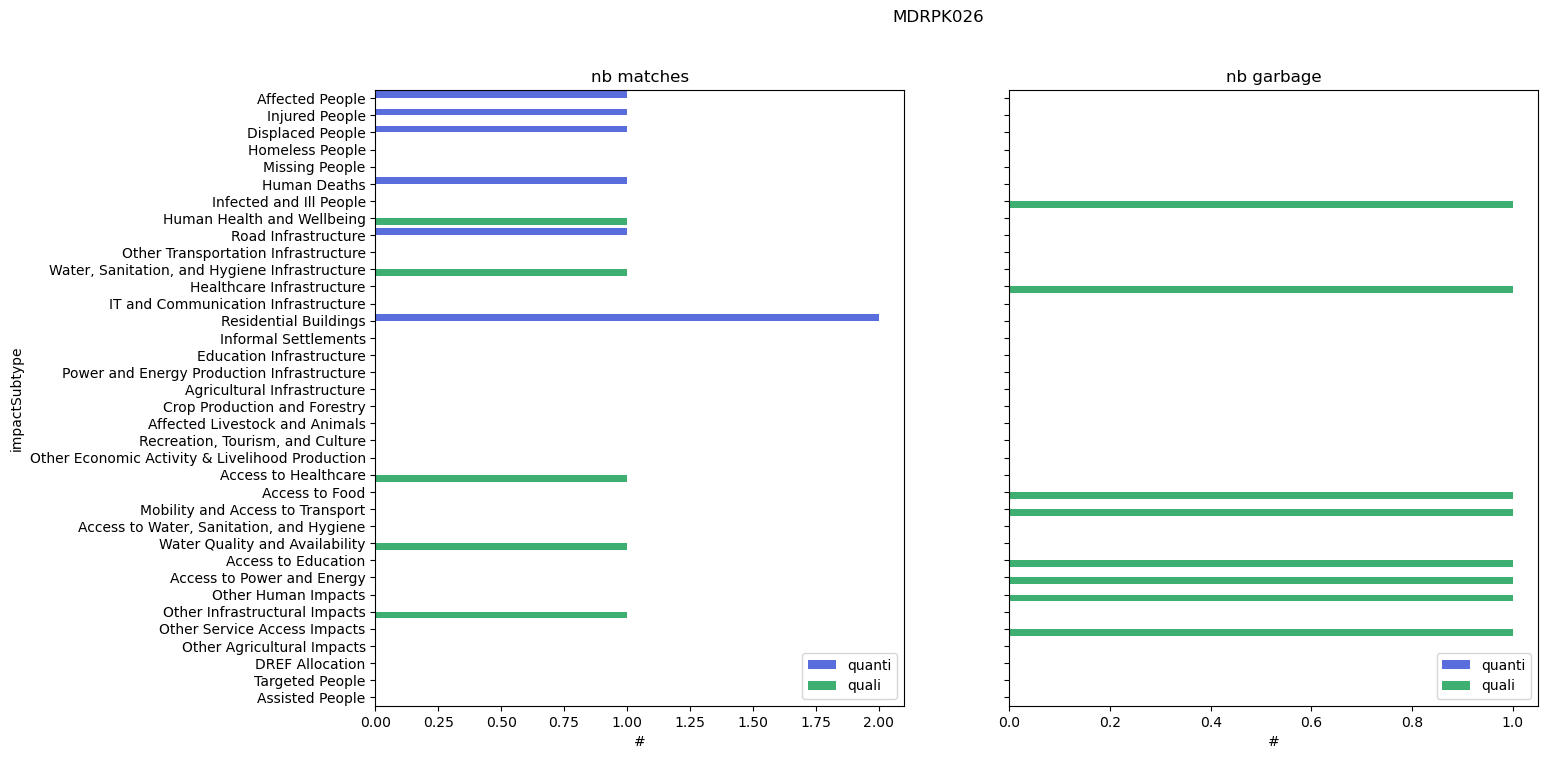

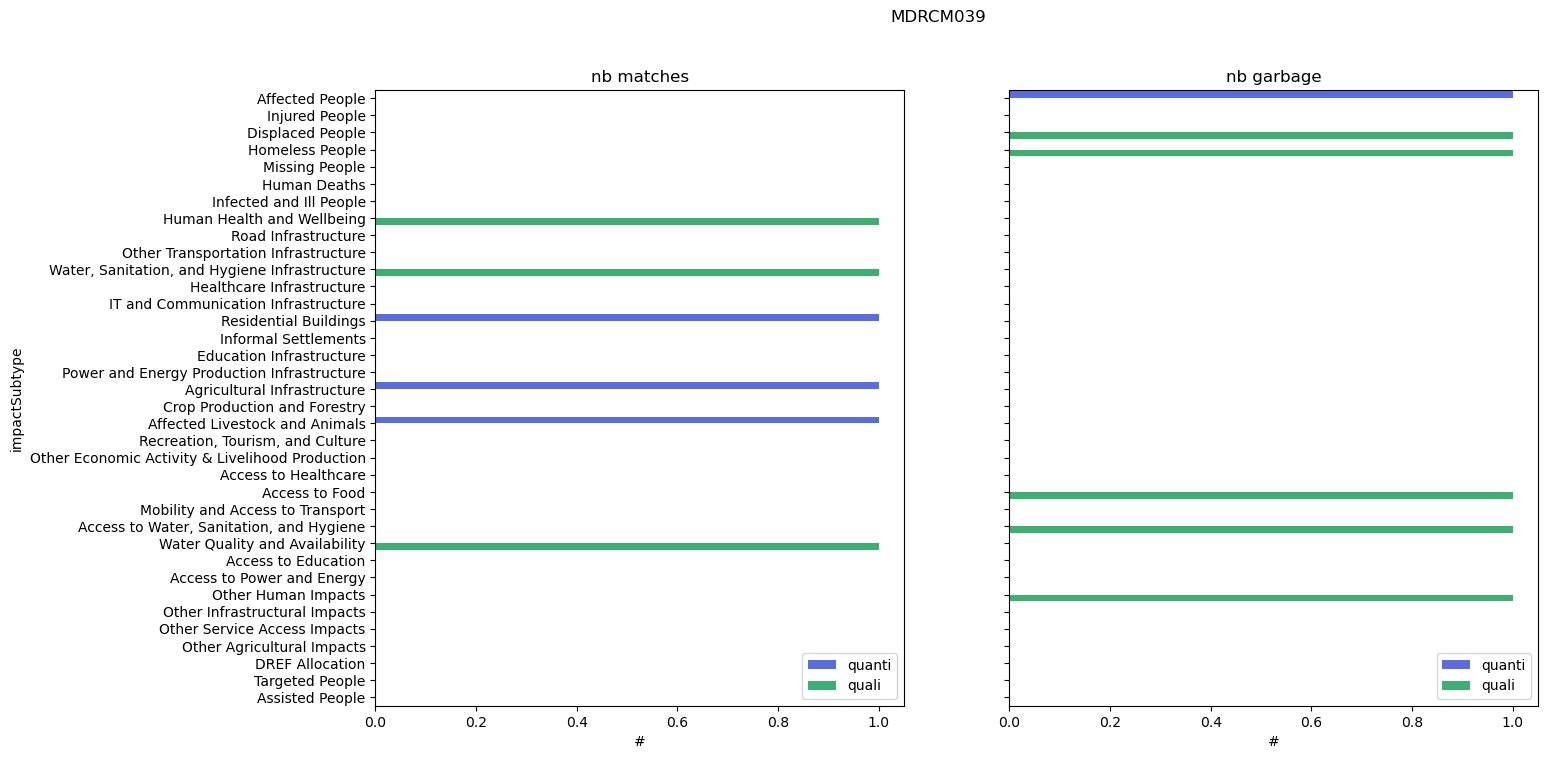

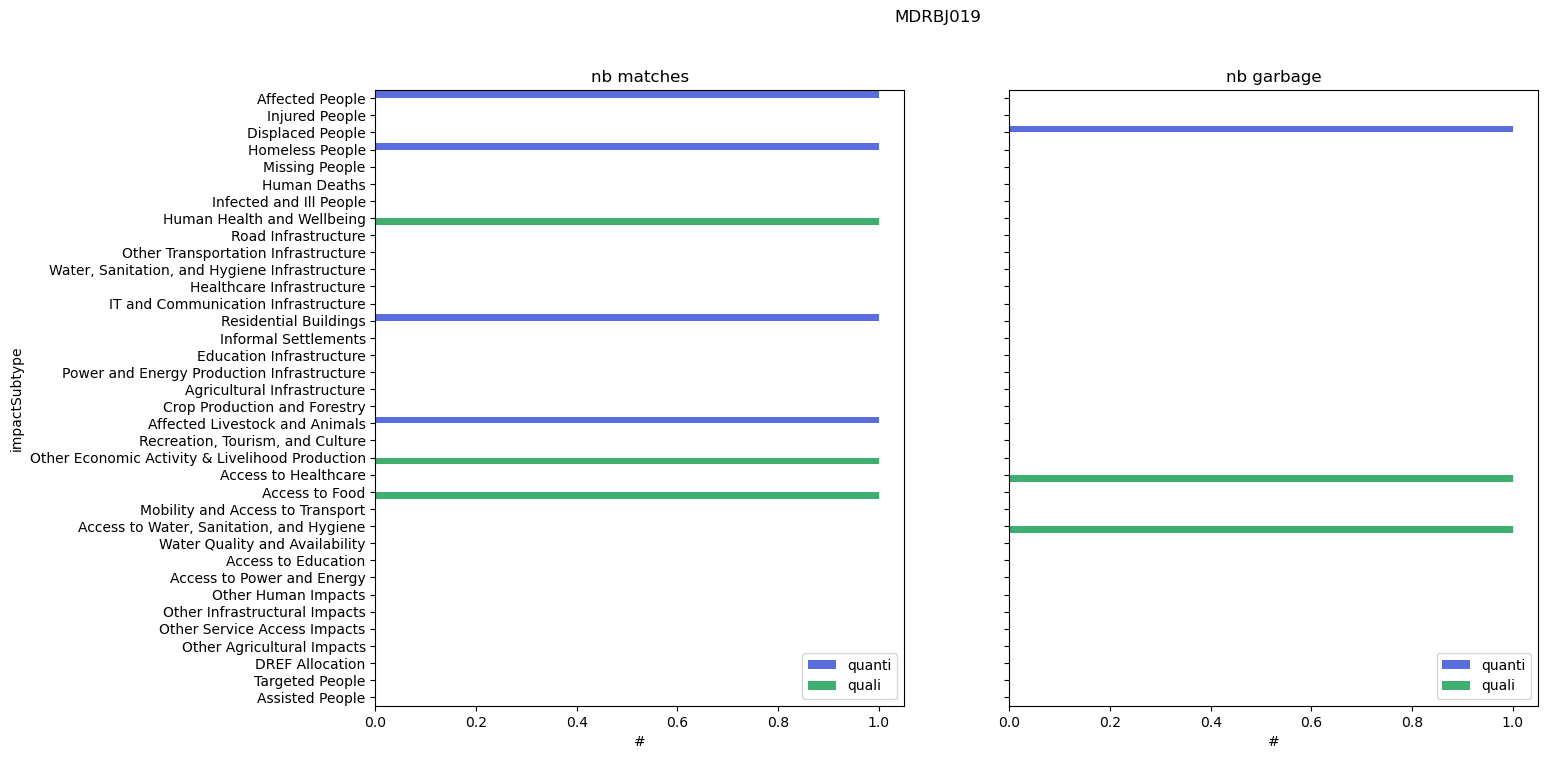

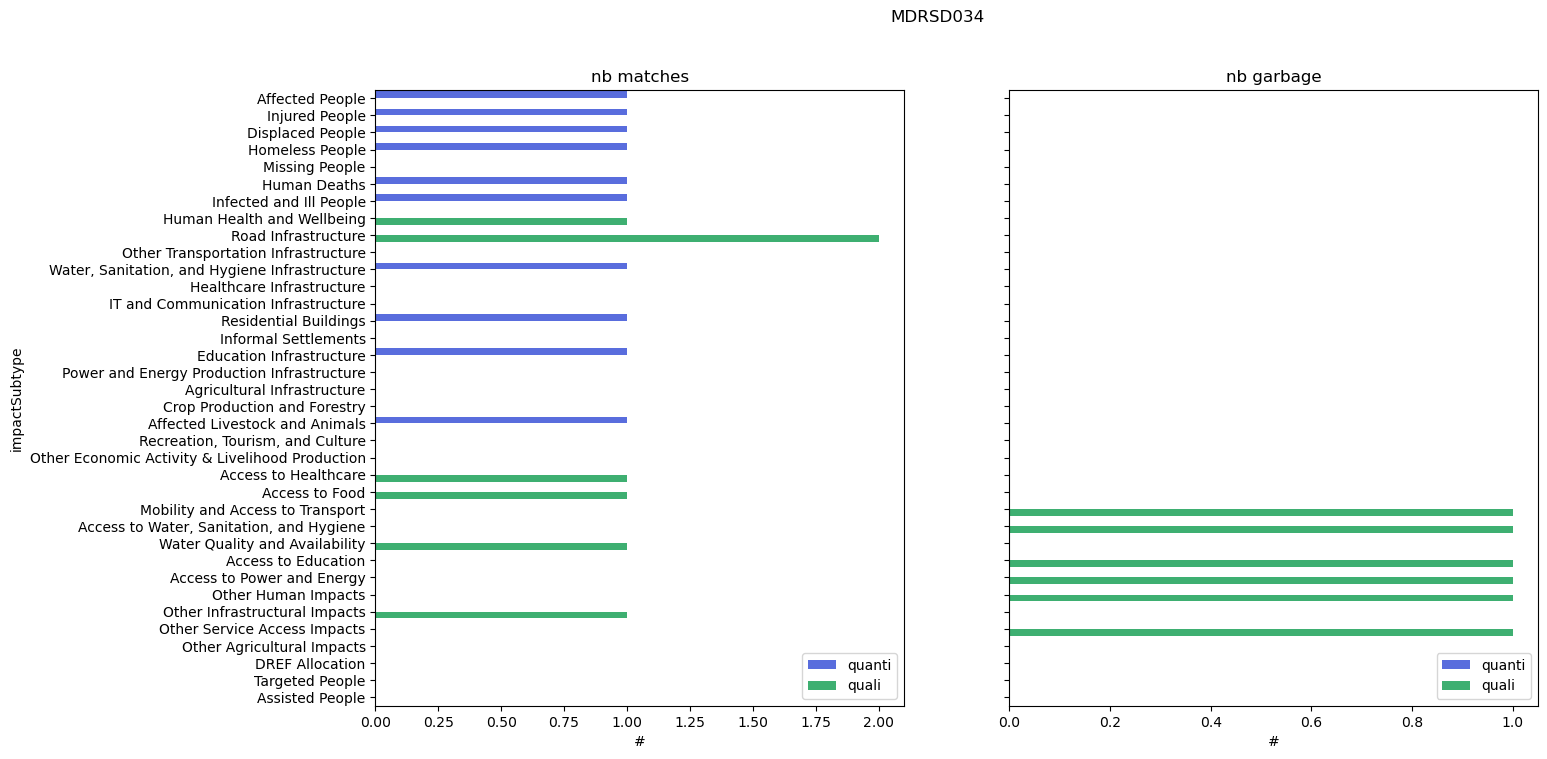

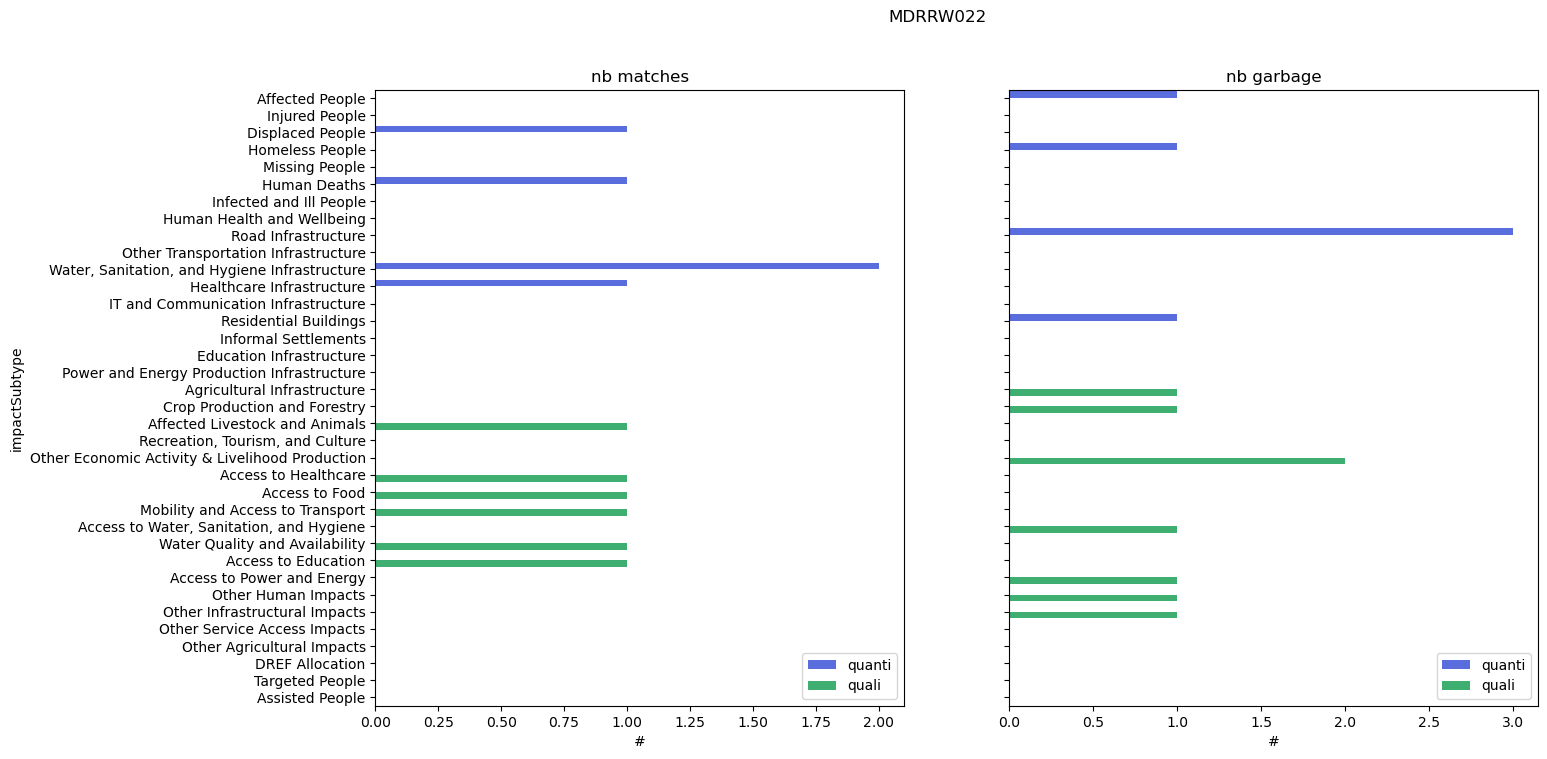

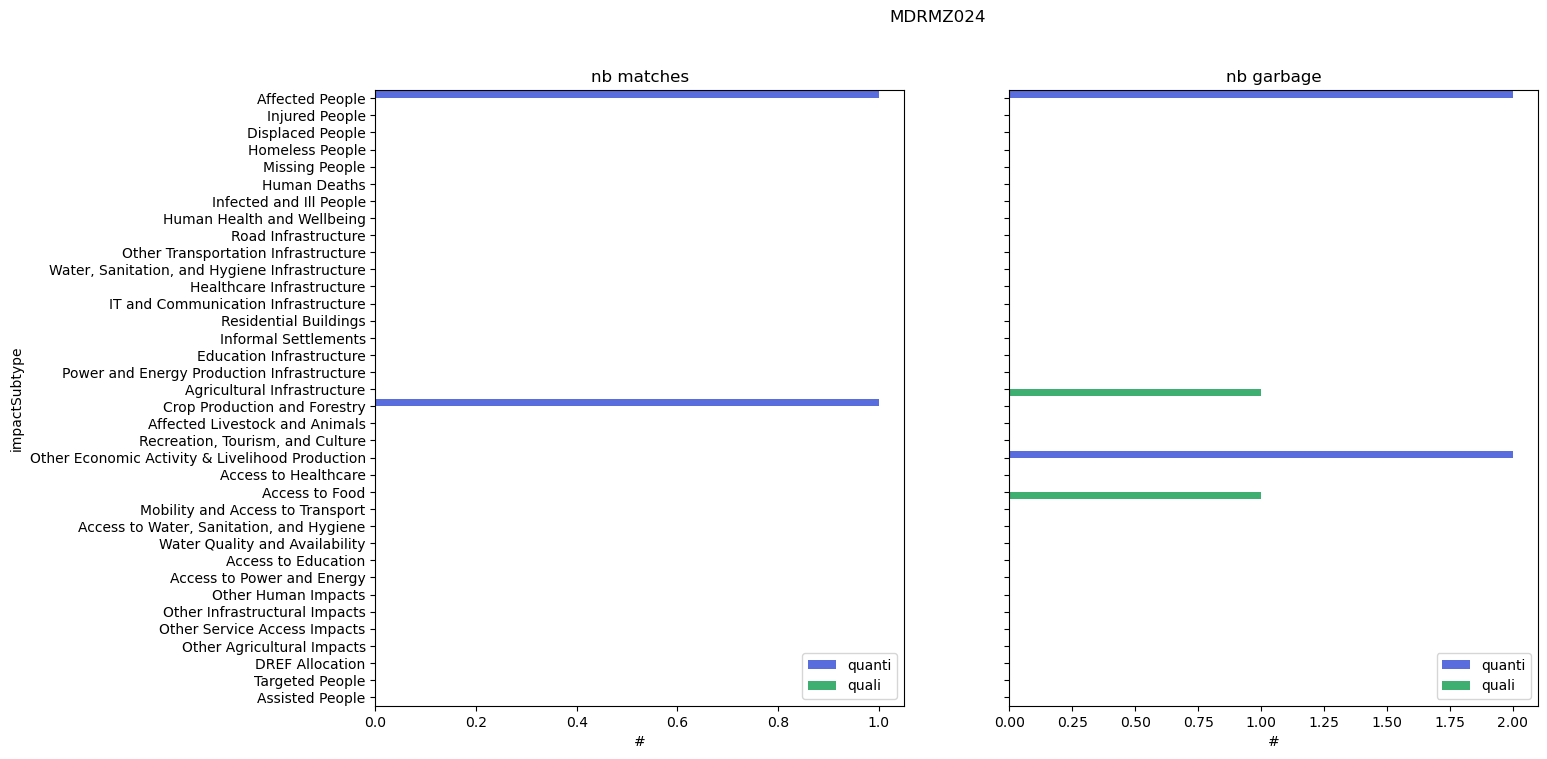

In [134]:
#coverage vs garbage per impactSubtype for each report
appeals = labelled_df.appealCode.unique()
value_vars = ["nb matches", "nb garbage"]#["coverage matches", "garbage"]#["nb matches", "nb garbage"]
label = "#"
yvar="impactSubtype"
#fig, axes = plt.subplots(len(appeals), 2, figsize=(15, 10), sharey=True)
#choose plotting cols
subplot_col = "match"#"quanti""match"
hue_col = "quanti"#"quanti""match"
palette_rel = ["#E61F04", "#f46c6c","#177093","#27a4d6"]
palette_rel = ["#435EF3", "#2bc26f","#435EF3", "#2bc26f", "#435EF3", "#2bc26f"]

for i, appeal in enumerate(appeals):
    ext_appeal = extracted_df_filter[extracted_df_filter["appealCode"] == appeal]
    lab_appeal = labelled_df_filter[labelled_df_filter["appealCode"] == appeal]
    matched_appeal = matched_df_filter2[matched_df_filter2["appealCode"] == appeal]
    coverage_df_match_appeal_subtype = make_coverage_accuracy_df(ext_appeal, lab_appeal, matched_appeal, group_key="impactSubtype", group_keys=IMPACT_SUBTYPES).reset_index(drop=False, names=["impactSubtype"])
    plot_df = coverage_df_match_appeal_subtype.melt(id_vars=[yvar, "quanti"], value_vars=value_vars, var_name="match", value_name="value")
    fig, axes = plot_coverage_match_v2(plot_df, subplot_col, hue_col, yvar=yvar, value_col="value", palette=palette_rel, add_avg=add_avg)
    [ax.set_xlabel(label) for ax in axes]
    fig.suptitle(appeal)

In [135]:
appeal="MDRCM039"
ext_appeal = extracted_df_filter[extracted_df_filter["appealCode"] == appeal]
lab_appeal = labelled_df_filter[labelled_df_filter["appealCode"] == appeal]
matched_appeal = matched_df[matched_df["appealCode"] == appeal]
matched_appeal_flt = matched_df_filter2[matched_df_filter2["appealCode"] == appeal]
coverage_df_match_appeal_subtype = make_coverage_accuracy_df(ext_appeal, lab_appeal, matched_appeal_flt, group_key="impactSubtype", group_keys=["Targeted People"]).reset_index(drop=False, names=["impactSubtype"])

In [136]:
coverage_df_match_appeal_subtype

,impactSubtype,nb labelled,nb extracted,coverage,nb matches,coverage matches,nb garbage,garbage,garbage/coverage,quanti
0,Targeted People,0,0,NaN,0,NaN,0,0,NaN,quanti
1,Targeted People,0,0,NaN,0,NaN,0,0,NaN,quali


In [137]:
print_match(matched_appeal[matched_appeal["match_sim"] < 0.6])

,appealCode,impactSubtype,impactSubtype_matched,impactValue,impactValue_matched,impactUnit,impactUnit_matched,location,location_matched,impactSubtype_sim,...,startYear_sim,startMonth_sim,startDay_sim,endYear_sim,endMonth_sim,endDay_sim,hazards_sim,match_sim,valueAnnotation,annotation_matched
51,MDRCM039,Targeted People,Affected People,4800.000000,400.00,people,people,"['Extrême-Nord', 'Mayo Danay division', 'Logon...",['Ndoukoula district'],0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.000000,0.500000,"['People Targeted: 4,800 people']","['Notably, in the Diamar division, where Ndouk..."
52,MDRCM039,Targeted People,Affected People,4800.000000,200.00,people,people,"['Extrême-Nord', 'Mayo Danay division', 'Logon...",['Mokolo district'],0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.000000,0.500000,"['People Targeted: 4,800 people']","['Notably, in the Diamar division, where Ndouk..."
53,MDRCM039,DREF Allocation,Affected People,448994.353894,158620.00,EUR,null,"['Far North region', 'Extrême-Nord', 'Logone e...",[],0.0,...,1.0,0.0,0.0,1.0,1.0,1.0,1.000000,0.304348,"['DREF Allocation: CHF 421,471']","[""Appeal MDRCM039 Country Cameroon Hazard Floo..."
54,MDRCM039,DREF Allocation,Affected People,448994.353894,400.00,EUR,people,"['Far North region', 'Extrême-Nord', 'Logone e...",['Ndoukoula district'],0.0,...,1.0,0.0,0.0,1.0,1.0,1.0,1.000000,0.304348,"['DREF Allocation: CHF 421,471']","['Notably, in the Diamar division, where Ndouk..."
55,MDRCM039,DREF Allocation,Affected People,448994.353894,200.00,EUR,people,"['Far North region', 'Extrême-Nord', 'Logone e...",['Mokolo district'],0.0,...,1.0,0.0,0.0,1.0,1.0,1.0,1.000000,0.304348,"['DREF Allocation: CHF 421,471']","['Notably, in the Diamar division, where Ndouk..."
58,MDRCM039,Agricultural Infrastructure,Crop Production and Forestry,29.980000,29.98,km**2 of crop production and forestry,km**2 of crop production and forestry,"['Logone et Chari', 'Mayo Danay']",['Far North region'],0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.000000,0.558830,['The provisional report consolidated by the w...,['The provisional report consolidated by the w...
61,MDRCM039,Displaced People,Other Infrastructural Impacts,NaN,NaN,null,unknown,"['Yagoua', 'Blangoua', 'Mackary', 'Zina', 'Mag...","['Mayo Danay division', 'Yagoua']",0.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.000000,0.592593,['Tens of thousands of victims are currently l...,['The peak of the floods was recorded on Augus...
62,MDRCM039,Homeless People,Other Infrastructural Impacts,NaN,NaN,null,unknown,"['Yagoua', 'Blangoua', 'Mackary', 'Zina', 'Mag...","['Mayo Danay division', 'Yagoua']",0.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.000000,0.592593,['Tens of thousands of victims are currently l...,['The peak of the floods was recorded on Augus...
63,MDRCM039,Access to Food,Other Infrastructural Impacts,NaN,NaN,null,unknown,"['Far North region', 'Logone et Chari division...","['Mayo Danay division', 'Yagoua']",0.0,...,1.0,0.0,0.0,1.0,1.0,1.0,0.707107,0.496823,['The lack of communication with the community...,['The peak of the floods was recorded on Augus...
64,MDRCM039,"Access to Water, Sanitation, and Hygiene",Other Infrastructural Impacts,NaN,NaN,null,unknown,"['Logone et Chari division', 'Mayo Danay divis...","['Mayo Danay division', 'Yagoua']",0.0,...,1.0,0.0,0.0,1.0,1.0,1.0,1.000000,0.518519,['Water sources (wells and water points) have ...,['The peak of the floods was recorded on Augus...


In [138]:
print_match(matched_appeal)

,appealCode,impactSubtype,impactSubtype_matched,impactValue,impactValue_matched,impactUnit,impactUnit_matched,location,location_matched,impactSubtype_sim,...,startYear_sim,startMonth_sim,startDay_sim,endYear_sim,endMonth_sim,endDay_sim,hazards_sim,match_sim,valueAnnotation,annotation_matched
49,MDRCM039,Affected People,Affected People,158620.000000,400.00,people,people,"['Logone et Chari division', 'Mayo Danay divis...",['Ndoukoula district'],1.0,...,1.0,0.0,0.0,1.0,1.0,1.0,1.000000,0.826087,['The provisional report consolidated by the w...,"['Notably, in the Diamar division, where Ndouk..."
50,MDRCM039,Affected People,Affected People,158620.000000,200.00,people,people,"['Logone et Chari division', 'Mayo Danay divis...",['Mokolo district'],1.0,...,1.0,0.0,0.0,1.0,1.0,1.0,1.000000,0.826087,['The provisional report consolidated by the w...,"['Notably, in the Diamar division, where Ndouk..."
51,MDRCM039,Targeted People,Affected People,4800.000000,400.00,people,people,"['Extrême-Nord', 'Mayo Danay division', 'Logon...",['Ndoukoula district'],0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.000000,0.500000,"['People Targeted: 4,800 people']","['Notably, in the Diamar division, where Ndouk..."
52,MDRCM039,Targeted People,Affected People,4800.000000,200.00,people,people,"['Extrême-Nord', 'Mayo Danay division', 'Logon...",['Mokolo district'],0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.000000,0.500000,"['People Targeted: 4,800 people']","['Notably, in the Diamar division, where Ndouk..."
53,MDRCM039,DREF Allocation,Affected People,448994.353894,158620.00,EUR,null,"['Far North region', 'Extrême-Nord', 'Logone e...",[],0.0,...,1.0,0.0,0.0,1.0,1.0,1.0,1.000000,0.304348,"['DREF Allocation: CHF 421,471']","[""Appeal MDRCM039 Country Cameroon Hazard Floo..."
54,MDRCM039,DREF Allocation,Affected People,448994.353894,400.00,EUR,people,"['Far North region', 'Extrême-Nord', 'Logone e...",['Ndoukoula district'],0.0,...,1.0,0.0,0.0,1.0,1.0,1.0,1.000000,0.304348,"['DREF Allocation: CHF 421,471']","['Notably, in the Diamar division, where Ndouk..."
55,MDRCM039,DREF Allocation,Affected People,448994.353894,200.00,EUR,people,"['Far North region', 'Extrême-Nord', 'Logone e...",['Mokolo district'],0.0,...,1.0,0.0,0.0,1.0,1.0,1.0,1.000000,0.304348,"['DREF Allocation: CHF 421,471']","['Notably, in the Diamar division, where Ndouk..."
56,MDRCM039,Residential Buildings,Residential Buildings,8690.000000,8690.00,homes,homes,"['Logone et Chari division', 'Mayo Danay divis...",['Far North region'],1.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.000000,0.806380,['The provisional report consolidated by the w...,['The provisional report consolidated by the w...
57,MDRCM039,Affected Livestock and Animals,Affected Livestock and Animals,10178.000000,10178.00,affected animals,affected animals,"['Logone et Chari', 'Mayo Danay']",['Far North region'],1.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.000000,0.819700,['The provisional report consolidated by the w...,['The provisional report consolidated by the w...
58,MDRCM039,Agricultural Infrastructure,Crop Production and Forestry,29.980000,29.98,km**2 of crop production and forestry,km**2 of crop production and forestry,"['Logone et Chari', 'Mayo Danay']",['Far North region'],0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.000000,0.558830,['The provisional report consolidated by the w...,['The provisional report consolidated by the w...


In [139]:
print_match(matched_df_filter2[(matched_df_filter2["match_sim"]<0.6) & (matched_df_filter2["appealCode"]=="MDRKE058")])

,appealCode,impactSubtype,impactSubtype_matched,impactValue,impactValue_matched,impactUnit,impactUnit_matched,location,location_matched,impactSubtype_sim,...,startYear_sim,startMonth_sim,startDay_sim,endYear_sim,endMonth_sim,endDay_sim,hazards_sim,match_sim,valueAnnotation,annotation_matched


In [140]:
print_match(matched_appeal[matched_appeal["impactSubtype"]=="Access to Power and Energy"])

,appealCode,impactSubtype,impactSubtype_matched,impactValue,impactValue_matched,impactUnit,impactUnit_matched,location,location_matched,impactSubtype_sim,...,startYear_sim,startMonth_sim,startDay_sim,endYear_sim,endMonth_sim,endDay_sim,hazards_sim,match_sim,valueAnnotation,annotation_matched


In [141]:
matched_appeal[matched_appeal["impactSubtype"]=="Affected People"]#[["appealCode","impactSubtype", "impactSubtype_matched", "impactValue", "impactValue_matched", "impactUnit", "impactUnit_matched", "location", "location_matched", "impactSubtype_sim", "impactUnit_sim", "geometry_sim","hazards_sim","match_sim","valueAnnotation", "annotation_matched"]]

,impactSubtype,impactValue,impactValueMin,impactValueMax,impactValuePrecision,impactUnit,valueAnnotation,valid_errors_impactValue,country,location,...,endDay_sim,impactSubtype_sim,impactUnit_sim,geometry_sim,impactValue_sim,match_sim,impactValue_error,quanti,appealType,flag_remove_cat
49,Affected People,158620.0,NaN,NaN,exact,people,['The provisional report consolidated by the w...,0,['Cameroon'],"['Logone et Chari division', 'Mayo Danay divis...",...,1.0,1.0,1.0,1.0,0.0,0.826087,395.55,quanti,DREF Operation,False
50,Affected People,158620.0,NaN,NaN,exact,people,['The provisional report consolidated by the w...,0,['Cameroon'],"['Logone et Chari division', 'Mayo Danay divis...",...,1.0,1.0,1.0,1.0,0.0,0.826087,792.10,quanti,DREF Operation,False


In [142]:
print_match(matched_df_filter1[(matched_df_filter1["match_sim"]<0.6) & (matched_df_filter1["appealCode"]=="MDRBD022")])

,appealCode,impactSubtype,impactSubtype_matched,impactValue,impactValue_matched,impactUnit,impactUnit_matched,location,location_matched,impactSubtype_sim,...,startYear_sim,startMonth_sim,startDay_sim,endYear_sim,endMonth_sim,endDay_sim,hazards_sim,match_sim,valueAnnotation,annotation_matched
15,MDRBD022,Access to Healthcare,Other Infrastructural Impacts,NaN,NaN,null,null,"['Kurigram', 'Gaibandha', 'Lalmonirhat', 'Chat...","['Kurigram district', 'Gaibandha district', 'L...",0.0,...,1.0,1.0,0.0,1.0,1.0,1.0,0.707107,0.570748,['Six days of heavy rain and onrush of upstrea...,['It is also reported that embankments have be...
16,MDRBD022,Access to Healthcare,Other Infrastructural Impacts,NaN,NaN,null,null,"['Kurigram', 'Gaibandha', 'Lalmonirhat', 'Chat...","['Gaddimari area', 'Lalmonirhats Hatibandha']",0.0,...,1.0,1.0,0.0,1.0,1.0,1.0,0.707107,0.570748,['Six days of heavy rain and onrush of upstrea...,['of union affected 776 Emergency Plan of Acti...


In [143]:
print_match(matched_df[(matched_df["impactSubtype"]=="Informal Settlements")])

,appealCode,impactSubtype,impactSubtype_matched,impactValue,impactValue_matched,impactUnit,impactUnit_matched,location,location_matched,impactSubtype_sim,...,startYear_sim,startMonth_sim,startDay_sim,endYear_sim,endMonth_sim,endDay_sim,hazards_sim,match_sim,valueAnnotation,annotation_matched
173,MDRKE058,Informal Settlements,Infected and Ill People,10.0,8.0,informal settlements,people,"['Busia County', 'Kisumu', 'Homabay', 'Migori'...",['Garsen'],0.0,...,1.0,0.0,0.0,1.0,1.0,1.0,0.707107,0.280744,['49 camps have been set up within the last tw...,['October November December short rains season...
174,MDRKE058,Informal Settlements,Affected People,31015.0,31015.0,people,people,"['Nairobi County', 'Kware', 'Kibra', 'Viwandan...","['Nairobi County', 'Kware', 'Kibra', 'Viwandan...",0.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.000000,0.739130,"['In Nairobi County, 31,015 people (6,203 hous...","['In Nairobi County, 31,015 people (6,203 hous..."
504,MDRYE011,Informal Settlements,Informal Settlements,NaN,NaN,null,null,"['Al-Khamis camp', 'Al-Hasaba', 'Aser camp', '...",['Sanaa governorate'],1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,0.707107,0.838583,['the heavy rains affected 56 families in Al-K...,"[""Situation analysis Description of the disast..."


In [144]:
print_match(matched_df[(matched_df["impactSubtype"]=="Other Infrastructural Impacts")])

,appealCode,impactSubtype,impactSubtype_matched,impactValue,impactValue_matched,impactUnit,impactUnit_matched,location,location_matched,impactSubtype_sim,...,startYear_sim,startMonth_sim,startDay_sim,endYear_sim,endMonth_sim,endDay_sim,hazards_sim,match_sim,valueAnnotation,annotation_matched
126,MDRDZ011,Other Infrastructural Impacts,"Water, Sanitation, and Hygiene Infrastructure",NaN,NaN,null,undefined WASH structures,['Béchar'],['Béchar'],0.0,...,1.0,1.0,1.0,0.0,0.0,0.0,1.000000,0.481481,"['critical infrastructure, including 4 bridges...",['DREF Operation Algeria Flood 2024 Bechar App...
127,MDRDZ011,Other Infrastructural Impacts,Power and Energy Production Infrastructure,NaN,NaN,null,undefined power and energy production structures,['Béchar'],['Béchar'],0.0,...,1.0,1.0,1.0,0.0,0.0,0.0,1.000000,0.481481,"['critical infrastructure, including 4 bridges...",['DREF Operation Algeria Flood 2024 Bechar App...
171,MDRKE058,Other Infrastructural Impacts,Healthcare Infrastructure,11.0,7.0,undefined structures,healthcare structures,[],[],0.0,...,0.0,0.0,0.0,1.0,1.0,0.0,0.707107,0.282297,['economic activities of the areas have been s...,['October November December short rains season...
259,MDRNG041,Other Infrastructural Impacts,Other Economic Activity & Livelihood Production,NaN,NaN,null,null,"['Dantudu', 'Balakozo', 'Gidan Tudu', 'Tsitse']",[],0.0,...,1.0,0.0,0.0,1.0,1.0,1.0,1.000000,0.555556,"['The floods ravaged farmlands and livestock, ...","['The scale of destruction is unprecedented, w..."
288,MDRPK026,Other Infrastructural Impacts,Other Infrastructural Impacts,NaN,NaN,null,null,"['Balochistan', 'Khyber Pakhtunkhwa', 'Sindh',...","['Jacobabad', 'Naushero Feroz', 'Ghotki', 'Suk...",1.0,...,1.0,1.0,0.0,1.0,1.0,1.0,0.707107,0.941267,['The monsoon season causing significant infra...,"['Areas such as Jacobabad, Naushero Feroz, Gho..."
370,MDRRW022,Other Infrastructural Impacts,IT and Communication Infrastructure,NaN,NaN,null,null,"['Rutsiro', 'Muhanga', 'Ngororero', 'Rubavu', ...",[],0.0,...,1.0,1.0,1.0,1.0,0.0,0.0,1.000000,0.555556,"['8 national roads, 9 district roads and 26 br...","['From 1 to 6 May, Rwanda experienced continuo..."
371,MDRRW022,Other Infrastructural Impacts,Power and Energy Production Infrastructure,NaN,NaN,null,null,"['Rutsiro', 'Muhanga', 'Ngororero', 'Rubavu', ...",[],0.0,...,1.0,1.0,1.0,1.0,0.0,0.0,1.000000,0.555556,"['8 national roads, 9 district roads and 26 br...","['From 1 to 6 May, Rwanda experienced continuo..."
372,MDRRW022,Other Infrastructural Impacts,Access to Healthcare,NaN,NaN,null,null,"['Rutsiro', 'Muhanga', 'Ngororero', 'Rubavu', ...","['Muhanga', 'Ngororero', 'Mukamira', 'Rubenger...",0.0,...,1.0,1.0,1.0,1.0,0.0,0.0,1.000000,0.555556,"['8 national roads, 9 district roads and 26 br...","['From 1 to 6 May, Rwanda experienced continuo..."
373,MDRRW022,Other Infrastructural Impacts,Mobility and Access to Transport,NaN,NaN,null,null,"['Rutsiro', 'Muhanga', 'Ngororero', 'Rubavu', ...","['Muhanga', 'Ngororero', 'Mukamira', 'Rubenger...",0.0,...,1.0,1.0,1.0,1.0,0.0,0.0,1.000000,0.555556,"['8 national roads, 9 district roads and 26 br...","['From 1 to 6 May, Rwanda experienced continuo..."
374,MDRRW022,Other Infrastructural Impacts,Access to Education,NaN,NaN,null,null,"['Rutsiro', 'Muhanga', 'Ngororero', 'Rubavu', ...",[],0.0,...,1.0,1.0,1.0,1.0,0.0,0.0,1.000000,0.555556,"['8 national roads, 9 district roads and 26 br...","['From 1 to 6 May, Rwanda experienced continuo..."


In [145]:
matched_df[matched_df["match_sim"]<0.6]["impactUnit"].value_counts()

impactUnit
null                                     242
EUR                                       66
people                                    24
%                                          3
percent                                    2
km**2 of crop production and forestry      1
yuan                                       1
undefined structures                       1
informal settlements                       1
women                                      1
children under 5                           1
children                                   1
Name: count, dtype: int64

In [146]:
extracted_df[extracted_df["appealCode"]=="MDRMZ024"][["impactUnit", "flag_percent"]]

,impactUnit,flag_percent
47,people,False
48,people,False
49,people,False
50,people,False
51,km**2 of crop production and forestry,False
52,null,False
53,EUR,False
54,EUR,False
55,people,False
56,EUR,False


In [147]:
labelled_df[labelled_df["appealCode"]=="MDRRW022"]

,reportDate,impactSubtype,impactValue,impactUnit,impactValuePrecision,impactValueMin,impactValueMax,annotation,country,location,...,locationLowestAdmin,geocoding_country_flag,geocoding_osm_flag,locationOsm,locationPolygon,iso3_code,geometry,quanti,appealType,flag_remove_cat
474,2024-09-05,Affected People,51905.0,people,exact,NaN,NaN,"['From 1 to 6 May, Rwanda experienced continuo...",['Rwanda'],[],...,ADM_0,0,0,['Rwanda'],['Rwanda'],['RWA'],"MULTIPOLYGON (((29.04054 -2.74413, 29.04022 -2...",quanti,DREF Operation Final Report,False
475,2024-09-05,Human Deaths,137.0,people,exact,NaN,NaN,"['From 1 to 6 May, Rwanda experienced continuo...",['Rwanda'],[],...,ADM_0,0,0,['Rwanda'],['Rwanda'],['RWA'],"MULTIPOLYGON (((29.04054 -2.74413, 29.04022 -2...",quanti,DREF Operation Final Report,False
476,2024-09-05,Residential Buildings,5472.0,homes,exact,NaN,NaN,"['From 1 to 6 May, Rwanda experienced continuo...",['Rwanda'],[],...,ADM_0,0,0,['Rwanda'],['Rwanda'],['RWA'],"MULTIPOLYGON (((29.04054 -2.74413, 29.04022 -2...",quanti,DREF Operation Final Report,False
477,2024-09-05,Water Quality and Availability,NaN,null,approx,NaN,NaN,"['From 1 to 6 May, Rwanda experienced continuo...",['Rwanda'],[],...,ADM_0,0,0,['Rwanda'],['Rwanda'],['RWA'],"MULTIPOLYGON (((29.04054 -2.74413, 29.04022 -2...",quali,DREF Operation Final Report,False
478,2024-09-05,Road Infrastructure,NaN,null,approx,NaN,NaN,"['From 1 to 6 May, Rwanda experienced continuo...",['Rwanda'],[],...,ADM_0,0,0,['Rwanda'],['Rwanda'],['RWA'],"MULTIPOLYGON (((29.04054 -2.74413, 29.04022 -2...",quali,DREF Operation Final Report,False
479,2024-09-05,"Water, Sanitation, and Hygiene Infrastructure",NaN,WASH structures,approx,NaN,NaN,"['From 1 to 6 May, Rwanda experienced continuo...",['Rwanda'],[],...,ADM_0,0,0,['Rwanda'],['Rwanda'],['RWA'],"MULTIPOLYGON (((29.04054 -2.74413, 29.04022 -2...",quali,DREF Operation Final Report,False
480,2024-09-05,Crop Production and Forestry,10.0,km**2 of crop production and forestry,approx,10.0,NaN,"['From 1 to 6 May, Rwanda experienced continuo...",['Rwanda'],[],...,ADM_0,0,0,['Rwanda'],['Rwanda'],['RWA'],"MULTIPOLYGON (((29.04054 -2.74413, 29.04022 -2...",quanti,DREF Operation Final Report,False
481,2024-09-05,Affected Livestock and Animals,NaN,affected animals,approx,NaN,NaN,"['From 1 to 6 May, Rwanda experienced continuo...",['Rwanda'],[],...,ADM_0,0,0,['Rwanda'],['Rwanda'],['RWA'],"MULTIPOLYGON (((29.04054 -2.74413, 29.04022 -2...",quali,DREF Operation Final Report,False
482,2024-09-05,Displaced People,38000.0,people,approx,38000.0,NaN,"['From 1 to 6 May, Rwanda experienced continuo...",['Rwanda'],[],...,ADM_0,0,0,['Rwanda'],['Rwanda'],['RWA'],"MULTIPOLYGON (((29.04054 -2.74413, 29.04022 -2...",quanti,DREF Operation Final Report,False
483,2024-09-05,Residential Buildings,4933.0,homes,approx,NaN,NaN,"['From 1 to 6 May, Rwanda experienced continuo...",['Rwanda'],"['Rubavu', 'Nyabihu', 'Ngororero', 'Karongi', ...",...,ADM_1,0,0,"['Rubavu', 'Nyabihu', 'Ngororero', 'Karongi', ...","['Western Province', 'Western Province', 'West...",['RWA'],"MULTIPOLYGON (((29.0405 -2.73948, 29.0405 -2.7...",quanti,DREF Operation Final Report,False


In [148]:
labelled_df[labelled_df["appealCode"]=="MDRRW022"]

,reportDate,impactSubtype,impactValue,impactUnit,impactValuePrecision,impactValueMin,impactValueMax,annotation,country,location,...,locationLowestAdmin,geocoding_country_flag,geocoding_osm_flag,locationOsm,locationPolygon,iso3_code,geometry,quanti,appealType,flag_remove_cat
474,2024-09-05,Affected People,51905.0,people,exact,NaN,NaN,"['From 1 to 6 May, Rwanda experienced continuo...",['Rwanda'],[],...,ADM_0,0,0,['Rwanda'],['Rwanda'],['RWA'],"MULTIPOLYGON (((29.04054 -2.74413, 29.04022 -2...",quanti,DREF Operation Final Report,False
475,2024-09-05,Human Deaths,137.0,people,exact,NaN,NaN,"['From 1 to 6 May, Rwanda experienced continuo...",['Rwanda'],[],...,ADM_0,0,0,['Rwanda'],['Rwanda'],['RWA'],"MULTIPOLYGON (((29.04054 -2.74413, 29.04022 -2...",quanti,DREF Operation Final Report,False
476,2024-09-05,Residential Buildings,5472.0,homes,exact,NaN,NaN,"['From 1 to 6 May, Rwanda experienced continuo...",['Rwanda'],[],...,ADM_0,0,0,['Rwanda'],['Rwanda'],['RWA'],"MULTIPOLYGON (((29.04054 -2.74413, 29.04022 -2...",quanti,DREF Operation Final Report,False
477,2024-09-05,Water Quality and Availability,NaN,null,approx,NaN,NaN,"['From 1 to 6 May, Rwanda experienced continuo...",['Rwanda'],[],...,ADM_0,0,0,['Rwanda'],['Rwanda'],['RWA'],"MULTIPOLYGON (((29.04054 -2.74413, 29.04022 -2...",quali,DREF Operation Final Report,False
478,2024-09-05,Road Infrastructure,NaN,null,approx,NaN,NaN,"['From 1 to 6 May, Rwanda experienced continuo...",['Rwanda'],[],...,ADM_0,0,0,['Rwanda'],['Rwanda'],['RWA'],"MULTIPOLYGON (((29.04054 -2.74413, 29.04022 -2...",quali,DREF Operation Final Report,False
479,2024-09-05,"Water, Sanitation, and Hygiene Infrastructure",NaN,WASH structures,approx,NaN,NaN,"['From 1 to 6 May, Rwanda experienced continuo...",['Rwanda'],[],...,ADM_0,0,0,['Rwanda'],['Rwanda'],['RWA'],"MULTIPOLYGON (((29.04054 -2.74413, 29.04022 -2...",quali,DREF Operation Final Report,False
480,2024-09-05,Crop Production and Forestry,10.0,km**2 of crop production and forestry,approx,10.0,NaN,"['From 1 to 6 May, Rwanda experienced continuo...",['Rwanda'],[],...,ADM_0,0,0,['Rwanda'],['Rwanda'],['RWA'],"MULTIPOLYGON (((29.04054 -2.74413, 29.04022 -2...",quanti,DREF Operation Final Report,False
481,2024-09-05,Affected Livestock and Animals,NaN,affected animals,approx,NaN,NaN,"['From 1 to 6 May, Rwanda experienced continuo...",['Rwanda'],[],...,ADM_0,0,0,['Rwanda'],['Rwanda'],['RWA'],"MULTIPOLYGON (((29.04054 -2.74413, 29.04022 -2...",quali,DREF Operation Final Report,False
482,2024-09-05,Displaced People,38000.0,people,approx,38000.0,NaN,"['From 1 to 6 May, Rwanda experienced continuo...",['Rwanda'],[],...,ADM_0,0,0,['Rwanda'],['Rwanda'],['RWA'],"MULTIPOLYGON (((29.04054 -2.74413, 29.04022 -2...",quanti,DREF Operation Final Report,False
483,2024-09-05,Residential Buildings,4933.0,homes,approx,NaN,NaN,"['From 1 to 6 May, Rwanda experienced continuo...",['Rwanda'],"['Rubavu', 'Nyabihu', 'Ngororero', 'Karongi', ...",...,ADM_1,0,0,"['Rubavu', 'Nyabihu', 'Ngororero', 'Karongi', ...","['Western Province', 'Western Province', 'West...",['RWA'],"MULTIPOLYGON (((29.0405 -2.73948, 29.0405 -2.7...",quanti,DREF Operation Final Report,False


/var/folders/y5/t1z41tgj7dv50sm2_29dn8740000gp/T/ipykernel_3312/3991066840.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0, i].set_xticklabels(axes[0, i].get_xticklabels(), rotation=30)
/var/folders/y5/t1z41tgj7dv50sm2_29dn8740000gp/T/ipykernel_3312/3991066840.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1, i].set_xticklabels(axes[1, i].get_xticklabels(), rotation=30)
/var/folders/y5/t1z41tgj7dv50sm2_29dn8740000gp/T/ipykernel_3312/3991066840.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0, i].set_xticklabels(axes[0, i].get_xticklabels(), rotation=30)
/var/folders/y5/t1z41tgj7dv50sm2_29dn8740000gp/T/ipykernel_3312/3991066840.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of t

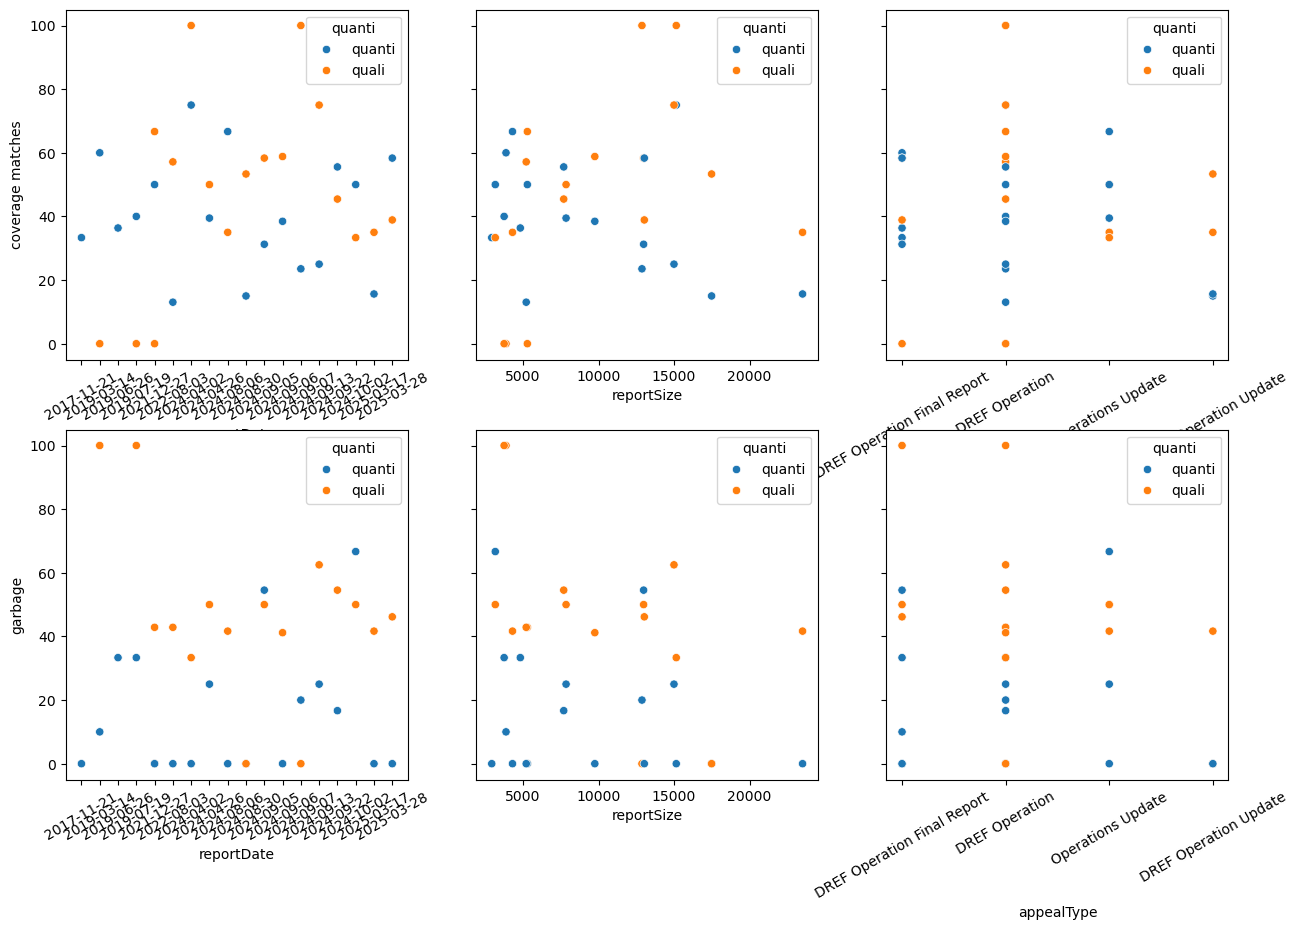

In [12]:
#inspect sensitivity to other variables e.g. date report type, lentgth
external_vars = ["reportDate", "reportSize", "appealType"]
fig, axes = plt.subplots(2, len(external_vars), figsize=(15, 10), sharey=True, sharex=False)
coverage_df_match_appeal = coverage_df_match_appeal.sort_values("reportDate")
for i, var in enumerate(external_vars):
    sns.scatterplot(coverage_df_match_appeal, x=var, y="coverage matches", hue="quanti", ax=axes[0, i])
    sns.scatterplot(coverage_df_match_appeal, x=var, y="garbage", hue="quanti", ax=axes[1, i])
    if var in ["reportDate", "appealType"]:
        axes[0, i].set_xticklabels(axes[0, i].get_xticklabels(), rotation=30)
        axes[1, i].set_xticklabels(axes[1, i].get_xticklabels(), rotation=30)
fig.savefig(DATA_FIGURE / f"coverage_matches_by_{yvar}_external_vars_valerr_th-{value_error_th}_sim_th-{sim_th}_{filename_match}.png", bbox_inches="tight", dpi=300)

In [150]:
#inspect sensitivity to thresholds

value_error_ths = np.arange(0.01, 0.3, 0.01)
sim_ths = np.arange(0.2, 1, 0.1)
vth_scores = []
for vth in value_error_ths:
    matched_df_filter = filter_matches(matched_df, value_error_th=vth, sim_th=0.6)
    make_coverage_accuracy_df(extracted_df, labelled_df, matched_df_filter, group_key=None)
    vth_scores.append(make_coverage_accuracy_df(extracted_df, labelled_df, matched_df_filter, group_key=None).set_index("quanti",drop=True)[["coverage matches", "garbage"]])

sth_scores = []
for sth in sim_ths:
    matched_df_filter = filter_matches(matched_df, value_error_th=0.1, sim_th=sth)
    sth_scores.append(make_coverage_accuracy_df(extracted_df, labelled_df, matched_df_filter, group_key=None).set_index("quanti",drop=True)[["coverage matches", "garbage"]])


Overall average quanti: 176 extracted, 336 labelled, 96 correct matches, 80 garbage matches
Overall average quali: 146 extracted, 174 labelled, 65 correct matches, 81 garbage matches
Overall average quanti: 176 extracted, 336 labelled, 96 correct matches, 80 garbage matches
Overall average quali: 146 extracted, 174 labelled, 65 correct matches, 81 garbage matches
Overall average quanti: 176 extracted, 336 labelled, 97 correct matches, 79 garbage matches
Overall average quali: 146 extracted, 174 labelled, 65 correct matches, 81 garbage matches
Overall average quanti: 176 extracted, 336 labelled, 97 correct matches, 79 garbage matches
Overall average quali: 146 extracted, 174 labelled, 65 correct matches, 81 garbage matches
Overall average quanti: 176 extracted, 336 labelled, 98 correct matches, 78 garbage matches
Overall average quali: 146 extracted, 174 labelled, 65 correct matches, 81 garbage matches
Overall average quanti: 176 extracted, 336 labelled, 98 correct matches, 78 garbage m

<Axes: >

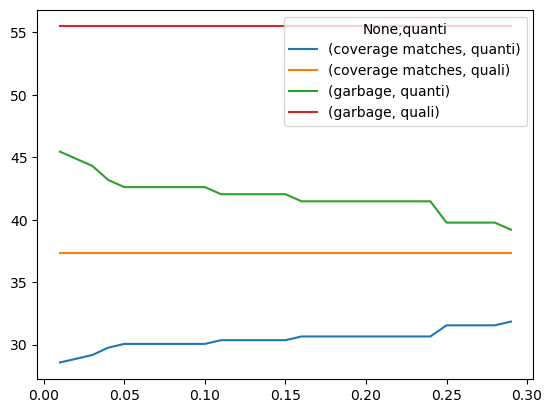

In [151]:
sensi_vth_df = pd.concat(vth_scores, keys=value_error_ths).unstack()
sensi_vth_df.plot()

<Axes: >

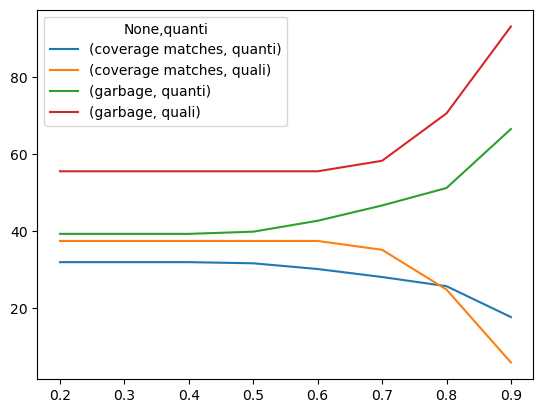

In [152]:
sensi_sth_df = pd.concat(sth_scores, keys=sim_ths).unstack()
sensi_sth_df.plot()

In [153]:
## Compare coverage by categories between labelled and extracted for all impacts

keys = ["meta-llama_llama-4-scout-17b-16e-instruct", "llama-3.1-8b-instant", "llama-3.3-70b-versatile"]
key = keys[0]
extracted_lab_name = f"post_processed_labelled_reports_DREF_target_{key}_v211025"
extracted_all_name = f"post_processed_flags_monty_200rep_{key}_v190925"

extracted_lab = pd.read_csv(DATA_OUT_PROC / (extracted_lab_name+".csv"))
extracted_df_long = pd.read_csv(DATA_OUT_PROC / (extracted_all_name+".csv"))


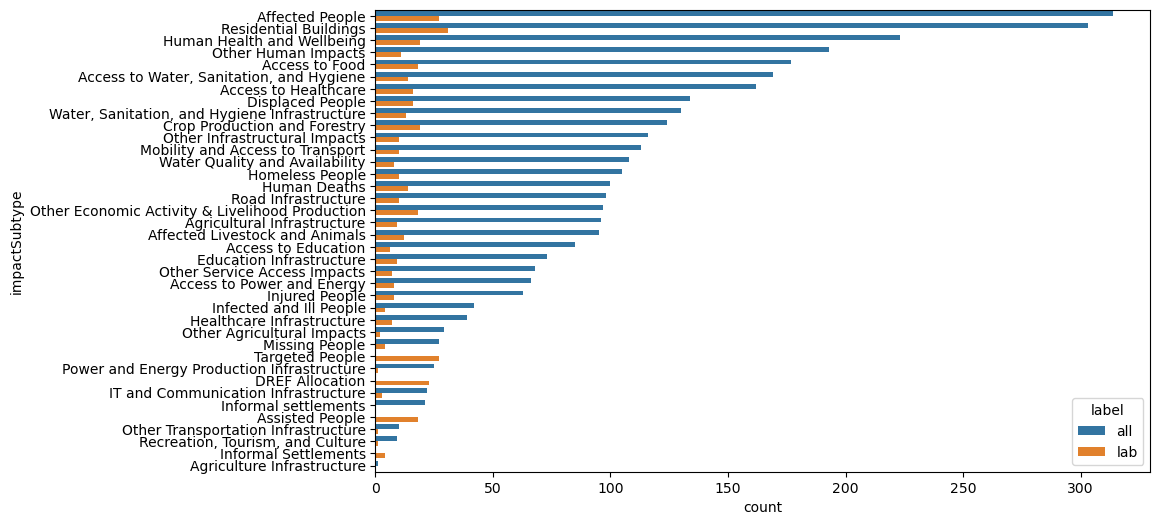

In [154]:
#merge dfs
extracted_lab["label"] ="lab"
extracted_df_long["label"] = "all"
extracted_df_all = pd.concat([extracted_lab, extracted_df_long])
plot_df = extracted_df_all.value_counts(["impactSubtype", "label"]).reset_index()
fig, ax = plt.subplots(1, 1, figsize=(10, 6))
sns.barplot(data=plot_df, x="count", y="impactSubtype", hue="label", axes=ax)
fig.savefig(DATA_FIGURE / f"impactSubtype_distr_lab_vs_200_{extracted_lab_name}.png", bbox_inches="tight", dpi=300)
